# BreastMetIMC → PhenoCycler : pipeline spatial avec **SpatialData** (JupyterLab local)

Cette version reprend l'analyse des scripts `IMCpipeline_1..5.R` (clustering, abondances, voisins, distances, réseaux). Les données sont organisées dans le format **[SpatialData](https://spatialdata.scverse.org/en/stable/)** (scverse) à partir des sorties du PhenoCycler :

| Entrée | Rôle | Élément SpatialData |
|---|---|---|
| `regXXX_cycYYY_chZZZ_<Marqueur>.tif` (1 TIF par canal) | images multiplexées | `Images` : `regXXX_image` (c, y, x), **pyramide multi-échelle en Zarr** |
| `labels_*.tif` (carte de segmentation) | contours / masques des cellules | `Labels` : `regXXX_labels` (valeur de pixel = `cell_id`) |
| `*_regXXX_compensated.fcs` | intensités moyennes par cellule + `x`, `y`, `size` | `Table` (AnnData) liée aux labels par `cell_id` ; `Shapes` : `regXXX_cells` (cercles) |
| `channelNames.txt` | marqueur de chaque canal, dans l'ordre cycle × canal | noms des canaux (`c`) et des variables de la table |

Chaque région est convertie **une seule fois** en un magasin `regXXX.zarr` (lecture paresseuse par blocs, pyramide pour l'affichage) ; les exécutions suivantes relisent directement le Zarr.

## Légende

* 🖐️ **INTERACTIF** : cellule qui demande une action ou une décision (chemins, paramètres, **annotation des clusters**, choix de la zone à afficher…).
* 🔍 **À INSPECTER** : résultat à regarder avant de continuer.
* ⚠️ **DIFFÉRENCE AVEC LA VERSION IMC / R** : adaptation imposée par les données PhenoCycler.

### Passages qui doivent rester interactifs

| Section | Pourquoi |
|---|---|
| 0.2 Chemins, taille de pixel, canaux par cycle | propres à l'acquisition |
| 0.4 Contrôle de la carte de labels | vérifier visuellement que la reconstruction des cellules est correcte |
| 1.1 Marqueurs retenus et transformation (cofacteur arcsinh) | les intensités PhenoCycler ne sont pas des comptes d'ions comme en IMC : le cofacteur 0,8 du R ne convient pas |
| 1.3 Nombre de clusters | `N_CLUSTERS` |
| **1.4 Annotation des clusters** | **étape experte manuelle** (pré-remplie par des règles de marqueurs, à corriger) |
| 1.6 Visualisation spatiale (zoom) | choix de la région, des canaux et de la fenêtre |
| 3–5 Seuils (voisins, proximité, effectifs), types cellulaires étudiés | choix biologiques |

## Différences avec la version IMC / R

⚠️ Le panel PhenoCycler n'est pas celui de l'IMC (pas de CD15, CD33, CD16, DCSIGN, COL, CD45RA/RO… mais CD31, INOS, Podoplanin). La liste des types cellulaires (`CLUSTERLEVELS`) est donc adaptée et **modifiable**.

⚠️ Le FCS PhenoCycler ne contient pas les voisins `NN1..NN7` ni `MajAxis` : les voisins sont recalculés à partir des centroïdes, et la morphologie (aire, grand axe, excentricité) est mesurée directement sur la carte de labels.

⚠️ Les comparaisons de groupes (LUM vs TNC, primaire vs métastase, organes) nécessitent un fichier `regions_metadata.xlsx` (une ligne par région). Sans lui, les analyses tournent mais les comparaisons sont ignorées.

## 0.1 Installation (environnement local)

Le notebook tourne dans un JupyterLab local (Windows, macOS ou Linux), **Python 3.10 à 3.12** recommandé. Le plus simple est de créer un environnement dédié **une seule fois**, dans un terminal (Anaconda Prompt sous Windows) :

```bash
conda create -n spatial python=3.12 -y
conda activate spatial
pip install spatialdata spatialdata-plot scanpy flowsom flowio tifffile scikit-image colorcet networkx plotly openpyxl statsmodels seaborn ipywidgets jupyterlab
jupyter lab
```

(sans conda : `python -m venv spatial` puis `spatial\Scripts\activate` sous Windows ou `source spatial/bin/activate` sous macOS/Linux, et la même ligne `pip install`.)

La cellule suivante vérifie les paquets et installe ceux qui manquent **dans le noyau Jupyter courant** (`%pip`). Après une installation, **redémarrez le noyau** (Kernel → Restart Kernel) puis reprenez à la cellule d'imports.

In [1]:
import importlib.util
_pkgs = {"spatialdata": "spatialdata", "spatialdata_plot": "spatialdata-plot", "scanpy": "scanpy", "flowsom": "flowsom",
         "flowio": "flowio", "tifffile": "tifffile", "skimage": "scikit-image", "colorcet": "colorcet", "seaborn": "seaborn",
         "networkx": "networkx", "plotly": "plotly", "openpyxl": "openpyxl", "statsmodels": "statsmodels", "ipywidgets": "ipywidgets"}
_missing = [pip for mod, pip in _pkgs.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("Installation de :", " ".join(_missing))
    get_ipython().run_line_magic("pip", "install -q " + " ".join(_missing))
    print("➡️  Redémarrez le noyau (Kernel → Restart Kernel) puis continuez à la cellule suivante.")
else:
    print("Dépendances OK")

Dépendances OK


In [2]:
import os, re, glob, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize, to_hex
from matplotlib.patches import Patch
import seaborn as sns
import colorcet as cc
import flowio, tifffile, zarr
import dask.array as da
from scipy import ndimage as ndi, stats
from scipy.spatial import cKDTree
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.interpolate import griddata
from skimage.segmentation import expand_labels
from skimage.measure import regionprops_table
import anndata as ad
import spatialdata as sd
import spatialdata_plot  # noqa: F401  (active l'accesseur sdata.pl)
from spatialdata.models import Image2DModel, Labels2DModel, ShapesModel, TableModel, get_channel_names
from spatialdata.transformations import Identity, Scale
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 90, "pdf.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False})
%matplotlib inline
print("spatialdata", sd.__version__)

spatialdata 0.8.0


## 0.2 Données et paramètres

> 🖐️ **INTERACTIF** — Organisation attendue du dossier (sur votre disque, ou un partage réseau monté) :
> ```
> RAW_DIR/
> ├── processed/stitched/reg001   reg001_cyc001_ch001_DAPI.tif, reg001_cyc001_ch002_Blank.tif, … (un TIF par canal)
> ├── labels/   labels_cy002_ch1.tif  (ou reg001_labels.tif, … : une carte par région)
> ├── processed\segm\segm-1\fcs\compensated      EXP100-…_reg001_compensated.fcs, … (un FCS par région)
> ├── channelNames.txt
> └── regions_metadata.xlsx   (optionnel : region, sample_id, Case, Anno, Tumor, Phenotype, Met, …)
> ```
> * `PIXEL_SIZE_UM` : taille du pixel (PhenoCycler-Fusion 20× ≈ 0,5068 µm ; CODEX ancien ≈ 0,377 µm). Sert à exprimer les distances en µm.
> * `COORD_ONE_BASED` : les `x`, `y` du FCS du processeur CODEX commencent à 1 (vérifié sur `reg001` : 100 % des centroïdes tombent dans une cellule avec ce décalage).
> * `REBUILD_ZARR` : `True` pour reconvertir les TIF même si le Zarr existe déjà.

In [3]:
# 🖐️ INTERACTIF
# Chemin du dossier de données. Sous Windows, utilisez r"D:\\PhenoCycler\\EXP100" ou "D:/PhenoCycler/EXP100".
RAW_DIR = r"D:\\ELOISE\\EXP112\\ROI_9x7"
PIXEL_SIZE_UM = 0.325
CHANNELS_PER_CYCLE = 4
COORD_ONE_BASED = True
REBUILD_ZARR = False
SHOW_FIGS = True

RAW_DIR = os.path.abspath(os.path.expanduser(os.environ.get("PHENO_RAW_DIR", RAW_DIR)))
if not os.path.isdir(RAW_DIR):
    raise FileNotFoundError(f"RAW_DIR introuvable : {RAW_DIR} — corrigez le chemin ci-dessus.")

IMAGES_DIR = os.path.join(RAW_DIR, "processed\\stitched\\reg001")
LABELS_DIR = os.path.join(RAW_DIR, "labels")
FCS_DIR = os.path.join(RAW_DIR, "processed\\segm\\segm-1\\fcs\\compensated")
CHANNELS_FILE = os.path.join(RAW_DIR, "channelNames.txt")
REGIONS_METADATA = os.path.join(RAW_DIR, "regions_metadata.xlsx")
ZARR_DIR = os.environ.get("PHENO_ZARR_DIR", os.path.join(RAW_DIR, "spatialdata"))
OUT_DIR = os.environ.get("PHENO_OUT_DIR", os.path.join(RAW_DIR, "Results_spatialdata"))
os.makedirs(ZARR_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)
SEED = 1234
for p in [IMAGES_DIR, LABELS_DIR, FCS_DIR, CHANNELS_FILE, REGIONS_METADATA]:
    print(("OK      " if os.path.exists(p) else "ABSENT  ") + p)

OK      D:\ELOISE\EXP112\ROI_9x7\processed\stitched\reg001
OK      D:\ELOISE\EXP112\ROI_9x7\labels
OK      D:\ELOISE\EXP112\ROI_9x7\processed\segm\segm-1\fcs\compensated
OK      D:\ELOISE\EXP112\ROI_9x7\channelNames.txt
ABSENT  D:\ELOISE\EXP112\ROI_9x7\regions_metadata.xlsx


## 0.3 Canaux, régions et fichiers associés

`channelNames.txt` donne le marqueur de chaque canal dans l'ordre cycle 1 canal 1, cycle 1 canal 2, … Les noms répétés (DAPI à chaque cycle, Blank, Empty) sont rendus uniques (`DAPI_cyc001`, `Blank_cyc001_ch2`…) car SpatialData exige des noms de canaux uniques.

🔍 **À INSPECTER** — le tableau de correspondance région → images / labels / FCS.

In [6]:
names = [l.strip() for l in open(CHANNELS_FILE, encoding="utf-8").read().splitlines()]
names = [n for n in names if n != ""]
chan = pd.DataFrame({"idx": range(1, len(names) + 1), "marker": names})
chan["cycle"] = (chan["idx"] - 1) // CHANNELS_PER_CYCLE + 1
chan["ch"] = (chan["idx"] - 1) % CHANNELS_PER_CYCLE + 1
chan["fcs_name"] = chan.apply(lambda r: f"cyc{r.cycle:03d}_ch{r.ch:03d}", axis=1)
dup = chan["marker"].duplicated(keep=False)
chan["name"] = np.where(~dup, chan["marker"],
                        np.where(chan["marker"] == "DAPI", "DAPI_cyc" + chan["cycle"].map("{:03d}".format),
                                 chan["marker"] + "_cyc" + chan["cycle"].map("{:03d}".format) + "_ch" + chan["ch"].astype(str)))
CHAN_BY_FCS = dict(zip(chan["fcs_name"], chan["name"]))
CHAN_BY_CYCCH = {(r.cycle, r.ch): r["name"] for _, r in chan.iterrows()}
display(chan.set_index("idx").T)

def region_of(path):
    m = re.search(r"(reg\d+)", os.path.basename(path))
    return m.group(1) if m else None

fcs_files = {region_of(p): p for p in sorted(glob.glob(os.path.join(FCS_DIR, "*.fcs")))}
image_files = {}
for p in sorted(glob.glob(os.path.join(IMAGES_DIR, "*.tif*"))):
    m = re.search(r"(reg\d+)_cyc(\d+)_ch(\d+)", os.path.basename(p))
    if m:
        image_files.setdefault(m.group(1), []).append((int(m.group(2)), int(m.group(3)), p))
label_candidates = sorted(glob.glob(os.path.join(LABELS_DIR, "*.tif*")))
REGIONS = sorted(fcs_files)

# 🖐️ INTERACTIF — si l'association automatique carte de labels ↔ région ne convient pas, renseignez LABEL_FILES à la main,
# p. ex. LABEL_FILES = {"reg001": ".../labels/labels_cy002_ch1.tif"}
LABEL_FILES = {}
for r in REGIONS:
    own = [p for p in label_candidates if region_of(p) == r]
    if own:
        LABEL_FILES[r] = own[0]
    elif len(label_candidates) == 1 and len(REGIONS) == 1:
        LABEL_FILES[r] = label_candidates[0]

display(pd.DataFrame({"FCS": {r: os.path.basename(fcs_files[r]) for r in REGIONS},
                      "nb TIF": {r: len(image_files.get(r, [])) for r in REGIONS},
                      "labels": {r: os.path.basename(LABEL_FILES.get(r, "—")) for r in REGIONS}}))

idx,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
marker,DAPI,Blank,Blank,Blank,DAPI,K8,K14,CD45,DAPI,Vimentin,Ecadherin,Empty,DAPI,PanCK,Empty,Empty,DAPI,Blank,Blank,Blank
cycle,1,1,1,1,2,2,2,2,3,3,3,3,4,4,4,4,5,5,5,5
ch,1,2,3,4,1,2,3,4,1,2,3,4,1,2,3,4,1,2,3,4
fcs_name,cyc001_ch001,cyc001_ch002,cyc001_ch003,cyc001_ch004,cyc002_ch001,cyc002_ch002,cyc002_ch003,cyc002_ch004,cyc003_ch001,cyc003_ch002,cyc003_ch003,cyc003_ch004,cyc004_ch001,cyc004_ch002,cyc004_ch003,cyc004_ch004,cyc005_ch001,cyc005_ch002,cyc005_ch003,cyc005_ch004
name,DAPI_cyc001,Blank_cyc001_ch2,Blank_cyc001_ch3,Blank_cyc001_ch4,DAPI_cyc002,K8,K14,CD45,DAPI_cyc003,Vimentin,Ecadherin,Empty_cyc003_ch4,DAPI_cyc004,PanCK,Empty_cyc004_ch3,Empty_cyc004_ch4,DAPI_cyc005,Blank_cyc005_ch2,Blank_cyc005_ch3,Blank_cyc005_ch4


,FCS,nb TIF,labels
reg001,EXP112-validation panel-28012026_reg001_compen...,20,labels_cy002_ch1.tif


## 0.4 Conversion en SpatialData (Zarr)

Pour chaque région :

1. **Images** : les TIF sont lus par blocs (`tifffile` → `dask`), empilés dans l'ordre des canaux, puis écrits en pyramide multi-échelle (×1, ×2, ×4, ×8) avec des blocs de 1024×1024 : l'affichage d'une vue d'ensemble ou d'un zoom ne lit que ce qui est nécessaire.
2. **Labels** : détection automatique du type de carte.
   * **Carte d'instances** (un entier par cellule, ex. `uint16`/`uint32`) → utilisée telle quelle et ré-indexée pour que la valeur de pixel = `cell_id` du FCS.
   * **Carte de contours colorés** (cas de `labels_cy002_ch1.tif` : 8 bits, seulement 11 valeurs pour 26 666 cellules — c'est un tracé des contours avec 11 couleurs, pas des identifiants). Les cellules sont alors **reconstruites** : chaque zone fermée par un contour devient une cellule (composantes connexes du fond, les très grandes = arrière-plan sont écartées), le contour est rattaché à la cellule voisine, puis chaque zone reçoit le `cell_id` du FCS dont le centroïde tombe dedans.
3. **Shapes** : un cercle par cellule (centroïde FCS, rayon = √(size/π)) — utile s'il n'y a pas de labels.
4. **Table** (AnnData) : intensités moyennes brutes (`layers["raw"]`), `obs` (`cell_id`, `x`, `y`, `size`, morphologie), `obsm["spatial"]`, liée à l'élément `regXXX_labels` (ou `regXXX_cells`) par `cell_id`.

Chaque élément est placé dans un système de coordonnées propre à la région (`reg001`, en pixels) et dans `reg001_um` (en µm, via `Scale(PIXEL_SIZE_UM)`).

In [8]:
MAX_CELL_AREA_PX = 20000   # 🖐️ au-delà, une zone fermée est considérée comme du fond (mode « contours »)

def read_fcs_table(path):
    f = flowio.FlowData(path)
    arr = np.asarray(f.as_array(preprocess=False), dtype=np.float32)
    keys = sorted(f.channels, key=int)
    pnn = [str(f.channels[k]["pnn"]) for k in keys]
    pns = [str(f.channels[k].get("pns") or "") for k in keys]
    df = pd.DataFrame(arr, columns=pnn)
    # vérification : le nom de marqueur du FCS ($PnS) doit correspondre à channelNames.txt
    for n, s in zip(pnn, pns):
        if n in CHAN_BY_FCS and s and s != chan.set_index("fcs_name").loc[n, "marker"]:
            print(f"⚠️ {n} : FCS='{s}' ≠ channelNames='{chan.set_index('fcs_name').loc[n, 'marker']}'")
    return df.rename(columns=CHAN_BY_FCS)


def load_image_stack(region):
    items = sorted(image_files.get(region, []))
    arrs, cnames = [], []
    for cyc, ch, p in items:
        z = zarr.open(tifffile.imread(p, aszarr=True), mode="r")
        a = da.from_zarr(z if hasattr(z, "shape") else z["0"])
        arrs.append(a)
        cnames.append(CHAN_BY_CYCCH.get((cyc, ch), os.path.splitext(os.path.basename(p))[0]))
    return (da.stack(arrs).rechunk((1, 1024, 1024)), cnames) if arrs else (None, [])


def labels_from_map(L, cells_xy, cell_ids):
    """Renvoie une carte int32 dont la valeur de pixel = cell_id, et un résumé du mode utilisé."""
    nvals = len(np.unique(L))
    if nvals < 0.5 * len(cell_ids):         # carte de contours colorés → reconstruction
        mode = f"contours ({nvals - 1} couleurs)"
        inner, _ = ndi.label(L == 0)        # connexité 4 : les contours 8-connexes ferment les cellules
        sz = np.bincount(inner.ravel())
        inner[np.isin(inner, np.where(sz > MAX_CELL_AREA_PX)[0])] = 0
        lab = expand_labels(inner, 1)
        lab[(L == 0) & (inner == 0)] = 0
    else:
        mode = "instances"
        lab = L.astype(np.int64)
    # appariement par centroïde (avec recherche 3×3 si le centroïde tombe sur un contour)
    H, W = lab.shape
    xi = np.clip(np.round(cells_xy[:, 0]).astype(int), 0, W - 1); yi = np.clip(np.round(cells_xy[:, 1]).astype(int), 0, H - 1)
    hit = lab[yi, xi]
    for dy, dx in [(0, 1), (1, 0), (0, -1), (-1, 0), (1, 1), (-1, -1), (1, -1), (-1, 1)]:
        miss = hit == 0
        if not miss.any(): break
        hit[miss] = lab[np.clip(yi[miss] + dy, 0, H - 1), np.clip(xi[miss] + dx, 0, W - 1)]
    lut = np.zeros(int(lab.max()) + 1, dtype=np.int32)
    seen = set(); n_dup = 0
    for cid, l in zip(cell_ids, hit):
        if l == 0: continue
        if l in seen: n_dup += 1; continue
        seen.add(l); lut[l] = cid
    out = lut[lab]
    stats_ = dict(mode=mode, matched=int((lut > 0).sum()), n_cells=len(cell_ids), dup=n_dup,
                  unmatched_regions=int(len(np.unique(lab)) - 1 - (lut > 0).sum()))
    return out, stats_


def build_region(region):
    t0 = time.time()
    fcs = read_fcs_table(fcs_files[region])
    fcs = fcs.rename(columns={"region": "region_num"})
    fcs["cell_id"] = fcs["cell_id"].astype(np.int64)
    off = 1 if COORD_ONE_BASED else 0
    xy = fcs[["x", "y"]].to_numpy(float) - off
    tr = {region: Identity(), f"{region}_um": Scale([PIXEL_SIZE_UM, PIXEL_SIZE_UM], axes=("y", "x"))}
    elements = {}
    img, cnames = load_image_stack(region)
    if img is not None:
        elements[f"{region}_image"] = Image2DModel.parse(img, dims=("c", "y", "x"), c_coords=cnames,
                                                         scale_factors=[2, 2, 2], chunks=(1, 1024, 1024), transformations=tr)
    report = {"region": region, "n_cells": len(fcs), "image_channels": len(cnames)}
    morpho = None
    if region in LABEL_FILES:
        L = tifffile.imread(LABEL_FILES[region])
        lab, st = labels_from_map(L, xy, fcs["cell_id"].to_numpy())
        report.update(st)
        elements[f"{region}_labels"] = Labels2DModel.parse(lab, dims=("y", "x"), scale_factors=[2, 2, 2], chunks=(1024, 1024), transformations=tr)
        morpho = pd.DataFrame(regionprops_table(lab, properties=("label", "area", "major_axis_length", "minor_axis_length",
                                                                  "eccentricity", "perimeter", "orientation")))
        morpho = morpho.rename(columns={"label": "cell_id", "area": "Area_px", "major_axis_length": "MajAxis_px",
                                        "minor_axis_length": "MinAxis_px", "eccentricity": "Eccentricity",
                                        "perimeter": "Perimeter_px", "orientation": "Orientation"})
    import geopandas as gpd
    from shapely.geometry import Point
    circles = gpd.GeoDataFrame({"radius": np.sqrt(fcs["size"].to_numpy() / np.pi)},
                               geometry=[Point(x, y) for x, y in xy], index=fcs["cell_id"].to_numpy())
    elements[f"{region}_cells"] = ShapesModel.parse(circles, transformations=tr)

    marker_cols = [c for c in fcs.columns if c in set(chan["name"])]
    obs = fcs[[c for c in fcs.columns if c not in marker_cols]].copy()
    obs["x_px"], obs["y_px"] = xy[:, 0], xy[:, 1]
    if morpho is not None:
        obs = obs.merge(morpho, on="cell_id", how="left")
    obs["region_id"] = region
    target = f"{region}_labels" if f"{region}_labels" in elements else f"{region}_cells"
    obs["element"] = pd.Categorical([target] * len(obs))
    obs.index = [f"{region}_{c}" for c in obs["cell_id"]]
    adata = ad.AnnData(X=fcs[marker_cols].to_numpy(np.float32), obs=obs,
                       var=pd.DataFrame(index=marker_cols))
    adata.layers["raw"] = adata.X.copy()
    adata.obsm["spatial"] = xy
    table = TableModel.parse(adata, region=target, region_key="element", instance_key="cell_id")
    sdata = sd.SpatialData(images={k: v for k, v in elements.items() if k.endswith("_image")},
                           labels={k: v for k, v in elements.items() if k.endswith("_labels")},
                           shapes={k: v for k, v in elements.items() if k.endswith("_cells")},
                           tables={"table": table})
    path = os.path.join(ZARR_DIR, f"{region}.zarr")
    if os.path.exists(path):
        import shutil; shutil.rmtree(path)
    sdata.write(path)
    report["seconds"] = round(time.time() - t0, 1)
    return report

reports = []
for r in REGIONS:
    path = os.path.join(ZARR_DIR, f"{r}.zarr")
    if os.path.exists(path) and not REBUILD_ZARR:
        _s = sd.read_zarr(path)
        _n_img = len(get_channel_names(_s[f"{r}_image"])) if f"{r}_image" in _s.images else 0
        if (r in LABEL_FILES) == (f"{r}_labels" in _s.labels) and _n_img == len(image_files.get(r, [])):
            print(f"{r} : Zarr existant réutilisé"); continue
        print(f"{r} : nouveaux fichiers (labels/images) détectés → reconversion")
    print(f"{r} : conversion…"); reports.append(build_region(r))
if reports:
    display(pd.DataFrame(reports))

reg001 : conversion…


,region,n_cells,image_channels,mode,matched,dup,unmatched_regions,seconds
0,reg001,118998,20,contours (11 couleurs),118997,1,44665,345.4


## 0.5 Chargement des régions

Chaque `regXXX.zarr` est relu (paresseusement : les images ne sont pas chargées en mémoire), puis les régions sont réunies dans un seul objet `sdata` avec une table commune.

In [9]:
sdatas = {r: sd.read_zarr(os.path.join(ZARR_DIR, f"{r}.zarr")) for r in REGIONS}
sdata = sd.concatenate(list(sdatas.values()), concatenate_tables=True) if len(sdatas) > 1 else sdatas[REGIONS[0]]
print(sdata)

no parent found for <ome_zarr.reader.Label object at 0x00000196A0BA4170>: None


SpatialData object, with associated Zarr store: D:\ELOISE\EXP112\ROI_9x7\spatialdata\reg001.zarr
├── Images
│     └── 'reg001_image': DataTree[cyx] (20, 13484, 17274), (20, 6742, 8637), (20, 3371, 4318), (20, 1685, 2159)
├── Labels
│     └── 'reg001_labels': DataTree[yx] (13484, 17274), (6742, 8637), (3371, 4318), (1685, 2159)
├── Shapes
│     └── 'reg001_cells': GeoDataFrame shape: (118998, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (118998, 20)
with coordinate systems:
    ▸ 'reg001', with elements:
        reg001_image (Images), reg001_labels (Labels), reg001_cells (Shapes)
    ▸ 'reg001_um', with elements:
        reg001_image (Images), reg001_labels (Labels), reg001_cells (Shapes)


🔍 **À INSPECTER (0.4)** — contrôle de la carte de labels : contours des cellules reconstruites sur le DAPI, sur une fenêtre de 400×400 pixels (modifiable).

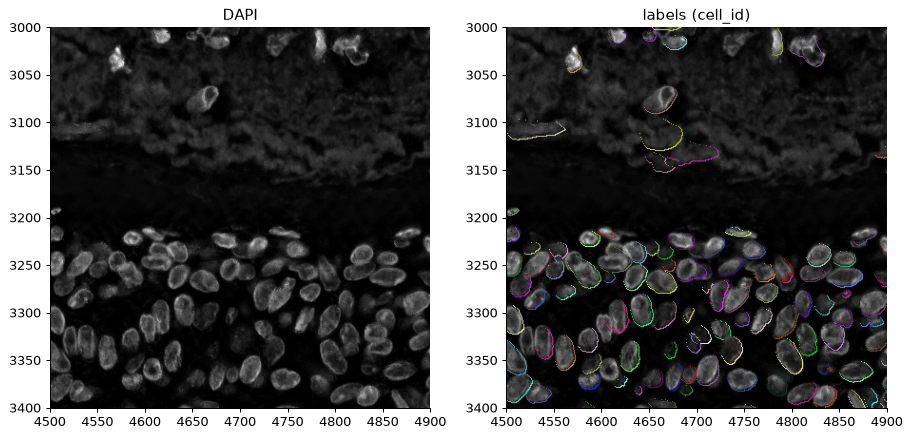

In [10]:
# 🖐️ INTERACTIF
QC_REGION = REGIONS[0]
QC_X0, QC_Y0, QC_SIZE = 4500, 3000, 400
if f"{QC_REGION}_labels" in sdata.labels and f"{QC_REGION}_image" in sdata.images:
    crop = sd.bounding_box_query(sdata.subset([f"{QC_REGION}_image", f"{QC_REGION}_labels"], filter_tables=False),
                                 axes=("x", "y"), min_coordinate=[QC_X0, QC_Y0], max_coordinate=[QC_X0 + QC_SIZE, QC_Y0 + QC_SIZE],
                                 target_coordinate_system=QC_REGION)
    dapi = [c for c in get_channel_names(sdata[f"{QC_REGION}_image"]) if c.startswith("DAPI")][:1]
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    crop.pl.render_images(f"{QC_REGION}_image", channel=dapi[0] if dapi else 0, cmap="gray").pl.show(coordinate_systems=QC_REGION, ax=axes[0], title="DAPI", colorbar=False)
    crop.pl.render_images(f"{QC_REGION}_image", channel=dapi[0] if dapi else 0, cmap="gray") \
        .pl.render_labels(f"{QC_REGION}_labels", fill_alpha=0.0, outline_alpha=1.0, contour_px=2) \
        .pl.show(coordinate_systems=QC_REGION, ax=axes[1], title="labels (cell_id)", colorbar=False)
    plt.show()
else:
    print("Pas d'image ou de labels pour", QC_REGION)

## 0.7 (Optionnel) Recalcul des intensités à partir du masque, avec correction du débordement latéral

Par défaut, les intensités par cellule sont celles du **FCS** (calculées par le logiciel du PhenoCycler). Cette section les **recalcule directement à partir des images et du masque des cellules**, ce qui permet :

* de **vérifier** les intensités du FCS (les deux doivent être très proches si la carte de labels est la bonne) ;
* de mesurer des canaux absents du FCS ;
* d'obtenir une seconde mesure **corrigée du débordement latéral (« lateral spillover »)**.

**Le débordement latéral.** Le signal d'une cellule « bave » sur ses voisines : flou optique, segmentation imparfaite, membranes accolées. Un lymphocyte collé à une cellule tumorale peut ainsi paraître faiblement K8+. Les méthodes publiées (REDSEA, Bai *et al.*, *Front. Immunol.* 2021) corrigent ce débordement en exploitant les zones de contact entre cellules. La correction utilisée ici reprend ce principe, avec un modèle simple estimé sur vos données :

1. Chaque cellule est découpée en **intérieur** et **bord** (anneau de `RING_PX` pixels). Chaque pixel de bord au contact d'une autre cellule *j* est rattaché à ce contact.
2. Pour chaque canal, une régression sur tous les contacts estime :
   `bord(i au contact de j) − intérieur(i) = α · intérieur(i) + γ · (intérieur(j) − intérieur(i))`
   * **α** : enrichissement propre du bord (positif pour un marqueur membranaire, négatif pour un marqueur nucléaire) ; il ne dépend pas du voisin et **n'est pas corrigé** ;
   * **γ** : fraction du bord qui prend le niveau du voisin = **débordement** (borné entre 0 et `GAMMA_MAX`).
3. Correction : `somme corrigée(i) = somme(i) − γ · Σ_j n_ij · (intérieur(j) − intérieur(i))`, où *n_ij* est le nombre de pixels de contact. Le signal venu d'un voisin plus brillant est retiré ; celui que la cellule a perdu vers un voisin plus terne lui est rendu. Entre deux cellules de même niveau, la correction est nulle.

Trois couches sont alors disponibles dans la table (`layers`), au choix pour la suite de l'analyse :

| `MEASUREMENT` | Contenu |
|---|---|
| `"fcs"` | intensités moyennes du FCS (par défaut, comportement initial) |
| `"mask_mean"` | moyenne des pixels de chaque cellule, recalculée sur le masque |
| `"mask_spillover"` | idem, corrigée du débordement latéral |

> 🖐️ **INTERACTIF** — `MEASUREMENT` (choix de la mesure utilisée ensuite), `RING_PX` (épaisseur du bord : 2 px ≈ 1 µm), `RECOMPUTE_MASK` (forcer le recalcul).
>
> Conditions : la région doit avoir une **carte de labels** et des **images**. Pour les canaux sans image, et pour les rares cellules du FCS absentes du masque, la valeur du FCS est conservée (signalé dans le contrôle ci-dessous). Le calcul se fait par bandes de `BAND_ROWS` lignes pour limiter la mémoire : quelques secondes par canal et par région.
>
> ⚠️ Sur un test simulé (deux populations exclusives, flou de 2 px), la correction réduit d'environ 70 % le signal parasite dans les cellules les plus contaminées (95ᵉ percentile). Elle ne le supprime pas entièrement, et ne corrige ni le bruit de fond ni le recouvrement spectral entre canaux.

In [11]:
# 🖐️ INTERACTIF
MEASUREMENT = "mask_spillover"          # "fcs" | "mask_mean" | "mask_spillover"
RING_PX = 2
GAMMA_MAX = 0.5
BAND_ROWS = 2048
RECOMPUTE_MASK = False
MEASUREMENT = os.environ.get("PHENO_MEASUREMENT", MEASUREMENT)

from scipy.ndimage import maximum_filter, minimum_filter

MAXI = np.iinfo(np.int64).max


def level0(elem):
    """Résolution pleine d'une image/labels SpatialData (pyramide ou image simple)."""
    import xarray as xr
    return elem if isinstance(elem, xr.DataArray) else sd.get_pyramid_levels(elem, n=0)


def measure_region(region, ring_px=RING_PX, band=BAND_ROWS):
    """Intensités moyennes par cellule à partir du masque + correction du débordement latéral.

    Renvoie (mean_all, mean_spill, gamma, alpha) : DataFrames cellules × canaux indexés par cell_id,
    et les coefficients de débordement (gamma) / d'enrichissement membranaire (alpha) par canal."""
    s = sdatas[region]
    L = da.asarray(level0(s[f"{region}_labels"]).data)
    I = level0(s[f"{region}_image"])
    chans = [str(c) for c in I.c.values]
    I = da.asarray(I.data)
    H, W = L.shape
    nlab = int(L.max().compute()) + 1
    nC = len(chans)
    area = np.zeros(nlab); inner_n = np.zeros(nlab)
    tot = np.zeros((nlab, nC)); inner = np.zeros((nlab, nC))
    parts = []
    size = 2 * ring_px + 1
    for y0 in range(0, H, band):
        y1 = min(H, y0 + band); a0 = max(0, y0 - ring_px); a1 = min(H, y1 + ring_px)
        Lb = np.asarray(L[a0:a1].compute(), dtype=np.int64)
        core = slice(y0 - a0, y0 - a0 + (y1 - y0))
        mx = maximum_filter(Lb, size=size)[core]
        mn0 = minimum_filter(Lb, size=size)[core]                                   # voit le fond (0)
        mnb = minimum_filter(np.where(Lb == 0, MAXI, Lb), size=size)[core]          # ignore le fond
        Lc = Lb[core]
        fg = Lc > 0
        ring = fg & ((mx != Lc) | (mn0 != Lc))                                      # pixels de bord de la cellule
        nb = np.where(mx != Lc, mx, np.where((mnb != Lc) & (mnb != MAXI), mnb, 0))  # cellule voisine au contact
        nb[~fg] = 0
        lc = Lc.ravel(); inn = (fg & ~ring).ravel(); cm = (nb > 0).ravel()
        area += np.bincount(lc, minlength=nlab)
        inner_n += np.bincount(lc[inn], minlength=nlab)
        keys = lc[cm] * nlab + nb.ravel()[cm]
        uk, inv = np.unique(keys, return_inverse=True)
        pn = np.bincount(inv, minlength=len(uk)).astype(float)
        psum = np.zeros((len(uk), nC))
        for ci in range(nC):
            im = np.asarray(I[ci, y0:y1].compute(), dtype=np.float64).ravel()
            tot[:, ci] += np.bincount(lc, weights=im, minlength=nlab)
            inner[:, ci] += np.bincount(lc[inn], weights=im[inn], minlength=nlab)
            psum[:, ci] = np.bincount(inv, weights=im[cm], minlength=len(uk))
        parts.append((uk, pn, psum))

    # agrégation des contacts (i, j) sur toutes les bandes
    uk = np.concatenate([p[0] for p in parts])
    agg = pd.DataFrame(np.column_stack([np.concatenate([p[1] for p in parts]), np.vstack([p[2] for p in parts])]))
    agg["key"] = uk
    agg = agg.groupby("key").sum()
    keys = agg.index.to_numpy(); pi, pj = keys // nlab, keys % nlab
    pn = agg[0].to_numpy(); psum = agg.drop(columns=0).to_numpy()

    ok = area > 0
    mean_all = np.full((nlab, nC), np.nan); mean_all[ok] = tot[ok] / area[ok, None]
    m_in = np.where(inner_n[:, None] >= 3, inner / np.maximum(inner_n, 1)[:, None], mean_all)   # intérieur (sans bord)
    ring_pair = psum / pn[:, None]

    # Modèle par canal, sur les zones de contact entre deux cellules i et j :
    #   bord_ij − intérieur_i = alpha · intérieur_i + gamma · (intérieur_j − intérieur_i)
    # alpha  : enrichissement propre du bord (marqueurs membranaires), indépendant du voisin ;
    # gamma  : fraction du bord « contaminée » par la cellule voisine (débordement latéral / flou optique).
    # Quand les deux cellules ont le même niveau, le terme gamma est nul : la correction est neutre.
    use = (pn >= 3) & (pi > 0) & (pj > 0)
    gamma = np.zeros(nC); alpha = np.zeros(nC)
    for ci in range(nC):
        xi, xj = m_in[pi[use], ci], m_in[pj[use], ci]
        y = ring_pair[use, ci] - xi
        w = np.sqrt(pn[use])
        good = np.isfinite(xi) & np.isfinite(xj) & np.isfinite(y)
        if good.sum() > 10:
            A = np.column_stack([xi, xj - xi])[good] * w[good, None]
            coef = np.linalg.lstsq(A, y[good] * w[good], rcond=None)[0]
            alpha[ci], gamma[ci] = coef[0], np.clip(coef[1], 0, GAMMA_MAX)

    # Correction : on retire du bord de i la part venant de j, et on lui rend la part partie chez j
    #   somme_corrigée_i = somme_i − gamma · Σ_j n_ij · (intérieur_j − intérieur_i)
    delta = np.zeros((nlab, nC))
    for ci in range(nC):
        d = pn * np.nan_to_num(m_in[pj, ci] - m_in[pi, ci]) * gamma[ci]
        delta[:, ci] = np.bincount(pi, weights=d, minlength=nlab)
    mean_spill = np.full((nlab, nC), np.nan)
    mean_spill[ok] = np.clip((tot[ok] - delta[ok]) / area[ok, None], 0, None)

    ids = np.where(ok)[0]; ids = ids[ids > 0]
    return (pd.DataFrame(mean_all[ids], index=ids, columns=chans),
            pd.DataFrame(mean_spill[ids], index=ids, columns=chans),
            pd.Series(gamma, index=chans), pd.Series(alpha, index=chans))


def write_table(s, t):
    s.tables["table"] = t
    if "tables/table" in s.elements_paths_on_disk():
        s.delete_element_from_disk("table")
    s.write_element("table")


SPILL_PARAMS = {}
for r in REGIONS:
    s = sdatas[r]; t = s.tables["table"]
    if f"{r}_labels" not in s.labels or f"{r}_image" not in s.images:
        # couches recopiées depuis le FCS pour que toutes les régions aient les mêmes couches
        if not {"mask_mean", "mask_spillover"}.issubset(t.layers):
            for layer in ("mask_mean", "mask_spillover"):
                t.layers[layer] = np.asarray(t.layers["raw"], dtype=np.float32).copy()
            t.uns["mask_measured_channels"] = []
            write_table(s, t)
        print(f"{r} : pas de labels ou pas d'images → valeurs FCS recopiées dans les couches mask_*"); continue
    if {"mask_mean", "mask_spillover"}.issubset(t.layers) and not RECOMPUTE_MASK:
        SPILL_PARAMS[r] = pd.DataFrame({k: v for k, v in t.uns.get("spillover_params", {}).items() if k in ("gamma", "alpha")})
        print(f"{r} : mesures sur masque déjà présentes (RECOMPUTE_MASK = True pour recalculer)"); continue
    t0 = time.time()
    m_all, m_spill, gamma, alpha = measure_region(r)
    fcs_raw = pd.DataFrame(np.asarray(t.layers["raw"]), columns=t.var_names, index=t.obs["cell_id"].to_numpy())
    measured = [c for c in t.var_names if c in m_all.columns]
    for layer, m in [("mask_mean", m_all), ("mask_spillover", m_spill)]:
        out = fcs_raw.copy()
        mm = m.reindex(out.index)[measured]
        out[measured] = mm.where(mm.notna(), out[measured])
        t.layers[layer] = out.to_numpy(np.float32)
    t.uns["mask_measured_channels"] = measured
    t.uns["spillover_params"] = {"gamma": gamma.to_dict(), "alpha": alpha.to_dict(), "ring_px": RING_PX}
    write_table(s, t)
    SPILL_PARAMS[r] = pd.DataFrame({"gamma": gamma, "alpha": alpha})
    n_miss = int(m_all.reindex(fcs_raw.index).iloc[:, 0].isna().sum())
    print(f"{r} : {len(measured)} canaux mesurés sur le masque, {n_miss} cellules du FCS absentes du masque "
          f"(valeur FCS conservée) — {time.time() - t0:.0f} s")

# objet combiné reconstruit avec les nouvelles couches
sdata = sd.concatenate(list(sdatas.values()), concatenate_tables=True) if len(sdatas) > 1 else sdatas[REGIONS[0]]
print("Couches disponibles :", list(sdata.tables["table"].layers))

reg001 : 20 canaux mesurés sur le masque, 1 cellules du FCS absentes du masque (valeur FCS conservée) — 113 s
Couches disponibles : ['raw', None, 'mask_mean', 'mask_spillover']


🔍 **À INSPECTER — contrôle des mesures sur masque**

1. **Concordance FCS ↔ masque** (`mask_mean`) : la corrélation doit être proche de 1 et le rapport médian proche de 1. Sinon, la carte de labels ne correspond pas aux images, ou le décalage de coordonnées est mauvais (`COORD_ONE_BASED`).
2. **Paramètres de débordement par canal** : γ (fraction de débordement) et α (enrichissement du bord). Un γ élevé sur un marqueur membranaire très exprimé (K8, PanCK, CD3…) est attendu. Sur DAPI ou Blank, γ reflète surtout le flou optique, et la correction y reste quasi neutre.
3. **Paires de marqueurs exclusifs** (deux lignées qui ne devraient pas être co-exprimées) : la corrélation, et la part de cellules « doubles positives » (au-dessus du 90ᵉ percentile pour les deux marqueurs), devraient **diminuer** après correction.

In [12]:
COFACTOR_QC = 150   # transformation utilisée seulement pour ce contrôle
EXCLUSIVE_PAIRS = [("CD3", "CD20"), ("CD3", "K8"), ("CD20", "K8"), ("CD68", "K8"), ("CD8", "CD20"), ("CD31", "K8"), ("CD3", "CD68")]

tab = sdata.tables["table"]
lay = {k: pd.DataFrame(np.asarray(tab.layers[v]), columns=tab.var_names) for k, v in
       [("fcs", "raw"), ("mask_mean", "mask_mean"), ("mask_spillover", "mask_spillover")] if v in tab.layers}
if "mask_mean" not in lay:
    print("Aucune mesure sur masque disponible.")
else:
    measured = sorted({c for r in REGIONS if "mask_measured_channels" in sdatas[r].tables["table"].uns
                       for c in sdatas[r].tables["table"].uns["mask_measured_channels"]}, key=list(tab.var_names).index)
    conc = pd.DataFrame({c: {"r(FCS, masque)": np.corrcoef(lay["fcs"][c], lay["mask_mean"][c])[0, 1],
                             "rapport médian masque/FCS": np.nanmedian(lay["mask_mean"][c] / lay["fcs"][c].replace(0, np.nan)),
                             "rapport médian corrigé/masque": np.nanmedian(lay["mask_spillover"][c] / lay["mask_mean"][c].replace(0, np.nan))}
                         for c in measured}).T.round(3)
    display(conc)
    display(pd.concat({r: p for r, p in SPILL_PARAMS.items() if len(p)}, axis=1).round(3))

    rows = []
    for a, b in EXCLUSIVE_PAIRS:
        if a in measured and b in measured:
            for k, d in lay.items():
                xa, xb = np.arcsinh(d[a] / COFACTOR_QC), np.arcsinh(d[b] / COFACTOR_QC)
                dp = ((xa > xa.quantile(.9)) & (xb > xb.quantile(.9))).mean() * 100
                rows.append({"paire": f"{a} / {b}", "mesure": k, "corrélation": stats.spearmanr(xa, xb)[0], "% doubles positives": dp})
    if rows:
        res = pd.DataFrame(rows).pivot(index="paire", columns="mesure")
        display(res.round(3))
        a, b = next((p for p in EXCLUSIVE_PAIRS if p[0] in measured and p[1] in measured))
        fig, axes = plt.subplots(1, len(lay), figsize=(4.5 * len(lay), 4), sharex=True, sharey=True)
        for ax, (k, d) in zip(np.atleast_1d(axes), lay.items()):
            ax.hexbin(np.arcsinh(d[a] / COFACTOR_QC), np.arcsinh(d[b] / COFACTOR_QC), gridsize=80, bins="log", cmap="viridis")
            ax.set_xlabel(a); ax.set_ylabel(b); ax.set_title(k)
        fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "Spillover_QC.pdf")); plt.show()
    else:
        print("Aucune paire de marqueurs exclusifs n'a d'image pour les deux canaux : contrôle des paires impossible.")

,"r(FCS, masque)",rapport médian masque/FCS,rapport médian corrigé/masque
DAPI_cyc001,0.995,0.949,1.0
Blank_cyc001_ch2,0.986,1.001,1.0
Blank_cyc001_ch3,0.993,1.004,1.0
Blank_cyc001_ch4,0.989,1.002,1.0
DAPI_cyc002,0.994,0.947,1.0
K8,0.993,1.017,1.0
K14,0.992,1.013,1.0
CD45,0.992,1.021,1.0
DAPI_cyc003,0.994,0.948,1.0
Vimentin,0.990,1.018,1.0


reg001       
                  gamma  alpha
DAPI_cyc001       0.224 -0.177
Blank_cyc001_ch2  0.354  0.005
Blank_cyc001_ch3  0.342  0.029
Blank_cyc001_ch4  0.346  0.017
DAPI_cyc002       0.221 -0.189
K8                0.500  0.564
K14               0.500  0.663
CD45              0.500  0.606
DAPI_cyc003       0.225 -0.186
Vimentin          0.404  0.172
Ecadherin         0.500  0.558
Empty_cyc003_ch4  0.397  0.148
DAPI_cyc004       0.227 -0.186
PanCK             0.500  0.524
Empty_cyc004_ch3  0.211 -0.224
Empty_cyc004_ch4  0.500  0.465
DAPI_cyc005       0.227 -0.187
Blank_cyc005_ch2  0.390  0.062
Blank_cyc005_ch3  0.348  0.035
Blank_cyc005_ch4  0.368  0.043

Aucune paire de marqueurs exclusifs n'a d'image pour les deux canaux : contrôle des paires impossible.


## 0.6 Types cellulaires, palettes et fonctions utilitaires

> 🖐️ **INTERACTIF** — `CLUSTERLEVELS` : liste (ordonnée) des types cellulaires utilisés pour l'annotation. Elle est adaptée au panel PhenoCycler (CD31 → `Endo` ; pas de marqueurs pour Gran/DC/NK ; un seul type B). Modifiez-la librement : toutes les analyses suivantes en dérivent (familles CK / stroma / lymphoïde / myéloïde déduites des noms).

In [13]:
# 🖐️ INTERACTIF
CLUSTERLEVELS = ["Tc", "Th", "Treg", "NK_T", "B",
                 "Mac_I", "Mac_II", "Mac_III", "Mac_IV",
                 "Endo", "Str_PS", "Str_V", "Str_VS",
                 "CK8", "CK8_E", "CK8_V", "CK14", "CK14_E", "CK14_EV", "CK8_14_E", "CK8_14_EV",
                 "CKlo", "CKlo_EV", "CKother", "NA"]

# Règles de pré-annotation (score = moyenne des z-scores des marqueurs listés) — simple suggestion, à corriger en 1.4
ANNOTATION_RULES = {
    "Tc": ["CD3", "CD8"], "Th": ["CD3", "CD4"], "Treg": ["CD3", "CD4", "FOXP3", "FOXP3"], "NK_T": ["CD3", "CD57"],
    "B": ["CD20"], "Mac_I": ["CD68"], "Mac_II": ["CD68", "CD163"], "Mac_III": ["CD163", "CD206"],
    "Mac_IV": ["CD68", "HLADR", "CD14"], "Endo": ["CD31"], "Str_PS": ["Podoplanin", "SMA"], "Str_V": ["Vimentin"],
    "Str_VS": ["Vimentin", "SMA"], "CK8": ["K8", "PanCK"], "CK8_E": ["K8", "Ecadh"], "CK8_V": ["K8", "Vimentin"],
    "CK14": ["K14"], "CK14_E": ["K14", "Ecadh"], "CK14_EV": ["K14", "Ecadh", "Vimentin"],
    "CK8_14_E": ["K8", "K14", "Ecadh"], "CK8_14_EV": ["K8", "K14", "Ecadh", "Vimentin"], "CKlo": ["PanCK"],
}
MIN_RULE_SCORE = 0.5

TYPELEVELS = ["CTRL", "LUM", "TNC", "HER2"]
SITELEVELS = ["PBC", "PBC_1YR", "PBC_tx", "PBC_recur", "GI", "PANC", "LIVER", "BRAIN", "OVARY", "PLEURA", "SPINE", "LUNG", "LN", "CTRL"]
TUMORLEVELS = ["IDC", "ILC", "IMC", "CTRL"]
CBB_PALETTE = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]


def maintype_of(ct):
    if ct in ("NA", "Neuron"): return "Other"
    if "CK" in ct: return "CK"
    if ct.startswith("Str") or ct == "Endo": return "Stroma"
    if ct.startswith("Mac") or ct in ("Gran", "DC"): return "Myl"
    if any(k in ct for k in ("T", "B", "NK")): return "Lym"
    return "Other"


def broad_group(ct):
    """9 familles de colorassignedbroad (ck8, ck14, ck8&14, ckother, other, str, lym, myeloid1, myeloid2/macs)."""
    if "CK8_14" in ct: return 2
    if ct.startswith("CK8"): return 0
    if ct.startswith("CK14"): return 1
    if "CK" in ct: return 3
    m = maintype_of(ct)
    return {"Other": 4, "Stroma": 5, "Lym": 6}.get(m, 8 if ct.startswith("Mac") else 7)


def hue_pal(n, h=(15, 375), c=100, l=65):
    """Équivalent exact de scales::hue_pal() (couleurs ggplot2)."""
    if n == 0: return []
    h0, h1 = h
    if (h1 - h0) % 360 < 1: h1 -= 360 / n
    out = []
    Xn, Yn, Zn = 95.047, 100.0, 108.883
    un = 4 * Xn / (Xn + 15 * Yn + 3 * Zn); vn = 9 * Yn / (Xn + 15 * Yn + 3 * Zn)
    M = np.array([[3.240479, -1.537150, -0.498535], [-0.969256, 1.875992, 0.041556], [0.055648, -0.204043, 1.057311]])
    for hh in np.linspace(h0, h1, n):
        U, V = c * np.cos(np.radians(hh)), c * np.sin(np.radians(hh))
        Y = Yn * ((l + 16) / 116) ** 3
        up, vp = U / (13 * l) + un, V / (13 * l) + vn
        X = 9.0 * Y * up / (4 * vp); Z = -X / 3 - 5 * Y + 3 * Y / vp
        rgb = M @ (np.array([X, Y, Z]) / 100)
        rgb = np.where(rgb > 0.00304, 1.055 * np.power(np.clip(rgb, 0, None), 1 / 2.4) - 0.055, 12.92 * rgb)
        out.append(to_hex(np.clip(rgb, 0, 1)))
    return out


def kovesi(name, n):
    return [to_hex(cc.cm[name](x)) for x in np.linspace(0, 1, n)]


def num2col(x, pal, ref=None):
    x = np.asarray(x, dtype=float)
    lo, hi = (np.nanmin(x), np.nanmax(x)) if ref is None else ref
    idx = np.clip(np.nan_to_num((x - lo) / (hi - lo + 1e-12) * (len(pal) - 1)).round(), 0, len(pal) - 1).astype(int)
    return [pal[i] for i in idx]


def setup_levels():
    """(Re)calcule les listes dérivées de CLUSTERLEVELS."""
    g = globals()
    g["MAC_TYPES"] = [c for c in CLUSTERLEVELS if c.startswith("Mac")]
    g["CK_TYPES"] = [c for c in CLUSTERLEVELS if "CK" in c]
    g["STR_TYPES"] = [c for c in CLUSTERLEVELS if c.startswith("Str") or c == "Endo"]
    g["LYM_TYPES"] = [c for c in CLUSTERLEVELS if maintype_of(c) == "Lym"]
    g["CLUSTERLEVELS_MACS"] = sorted(CLUSTERLEVELS, key=lambda c: (broad_group(c), CLUSTERLEVELS.index(c)))
    g["COLORASSIGNED"] = dict(zip(CLUSTERLEVELS, kovesi("rainbow_bgyrm_35_85_c69", len(CLUSTERLEVELS))))
    h9 = hue_pal(9)
    g["COLORASSIGNEDBROAD"] = {c: h9[broad_group(c)] for c in CLUSTERLEVELS}
    g["legendctype"] = pd.DataFrame({"V1": [f"ctype{i}" for i in range(1, len(CLUSTERLEVELS) + 1)],
                                     "allcelltypes": CLUSTERLEVELS, "maintype": [maintype_of(c) for c in CLUSTERLEVELS]})
    g["CT2NUM"] = {c: i + 1 for i, c in enumerate(CLUSTERLEVELS)}
    g["CTYPE_COLS"] = list(legendctype["V1"])

setup_levels()
COOLWARM = [to_hex(c) for c in plt.get_cmap("coolwarm")(np.linspace(0, 1, 100))]
RDBU_R = "RdBu_r"


class FigPDF:
    """Collecte de figures dans un PDF multi-pages (équivalent pdf(); …; dev.off())."""
    def __init__(self, name):
        self.path = os.path.join(OUT_DIR, name); self.pdf = PdfPages(self.path)
    def add(self, fig):
        self.pdf.savefig(fig, bbox_inches="tight")
        if SHOW_FIGS: plt.show()
        plt.close(fig)
    def __enter__(self): return self
    def __exit__(self, *a):
        self.pdf.close(); print("→", self.path)


def signif(p):
    if p is None or not np.isfinite(p): return "ns"
    return "****" if p < 1e-4 else "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"


def wilcox(a, b, paired=False):
    a = np.asarray(a, float); b = np.asarray(b, float)
    try:
        if paired: return stats.wilcoxon(a, b).pvalue
        a, b = a[~np.isnan(a)], b[~np.isnan(b)]
        return stats.mannwhitneyu(a, b, alternative="two-sided").pvalue if len(a) and len(b) else np.nan
    except ValueError:
        return np.nan


def ordered(values, levels):
    vals = list(dict.fromkeys(str(v) for v in values))
    return [l for l in levels if l in vals] + sorted(v for v in vals if v not in levels)


def site2_of(site):
    s = pd.Series(site, dtype="object").astype(str).copy()
    s[s.str.contains("PBC")] = "PBC"
    return s.values


def save_state(name, obj):
    with open(os.path.join(OUT_DIR, name), "wb") as f: pickle.dump(obj, f)


def load_state(name):
    with open(os.path.join(OUT_DIR, name), "rb") as f: return pickle.load(f)

# Partie 1 — Marqueurs, clustering, annotation (`IMCpipeline_1.R`)

## 1.1 Métadonnées des régions

Une région PhenoCycler = un échantillon (équivalent d'une carotte de TMA dans la version IMC). `regions_metadata.xlsx` (optionnel) associe chaque région à ses caractéristiques, avec les **mêmes noms de colonnes que `metadata.xlsx`** de la version IMC : `region`, `sample_id`, `Case` (patient), `Anno` (site), `Tumor`, `Phenotype` (LUM/TNC/…), `Met` (0/1), `Paired`.

> 🖐️ **INTERACTIF** — un modèle `regions_metadata_template.xlsx` est écrit dans le dossier de résultats : complétez-le, déposez-le sous `RAW_DIR/regions_metadata.xlsx` et relancez à partir d'ici.

In [14]:
META_COLS = ["sample_id", "Case", "Anno", "Tumor", "Phenotype", "Met", "Paired"]
if os.path.exists(REGIONS_METADATA):
    rmeta = pd.read_excel(REGIONS_METADATA, keep_default_na=False)
    rmeta["region"] = rmeta["region"].astype(str)
    print("Métadonnées chargées")
else:
    rmeta = pd.DataFrame({"region": REGIONS})
    tmpl = rmeta.assign(sample_id=REGIONS, Case="", Anno="", Tumor="", Phenotype="", Met="", Paired="")
    tmpl.to_excel(os.path.join(OUT_DIR, "regions_metadata_template.xlsx"), index=False)
    print("⚠️ Pas de regions_metadata.xlsx : modèle écrit dans", OUT_DIR)
for c in META_COLS:
    if c not in rmeta: rmeta[c] = rmeta["region"] if c == "sample_id" else ("NA" if c not in ("Met", "Paired") else 0)
rmeta["Met"] = pd.to_numeric(rmeta["Met"], errors="coerce").fillna(0).astype(int)
rmeta = rmeta.set_index("region")
HAS_GROUPS = rmeta["Phenotype"].astype(str).isin(["LUM", "TNC"]).any()
display(rmeta)

⚠️ Pas de regions_metadata.xlsx : modèle écrit dans D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata


,sample_id,Case,Anno,Tumor,Phenotype,Met,Paired
region,,,,,,,
reg001,reg001,NA,NA,NA,NA,0,0


## 1.2 Choix des marqueurs et transformation

Le R appliquait `asinh(x / 0.8)` à des **comptes d'ions IMC**. Les intensités PhenoCycler sont des niveaux de gris 16 bits (souvent 10²–10⁴) : un cofacteur de l'ordre de 100–500 est plus adapté.

> 🖐️ **INTERACTIF / 🔍 À INSPECTER** — `COFACTOR` et la liste des marqueurs exclus (DAPI, Blank, Empty par défaut). Les histogrammes ci-dessous doivent montrer, pour les marqueurs de lignée, une séparation nette entre population négative (pic autour de 0–1) et positive.

6 marqueurs : ['K8', 'K14', 'CD45', 'Vimentin', 'Ecadherin', 'PanCK']
Intensités utilisées : mask_spillover


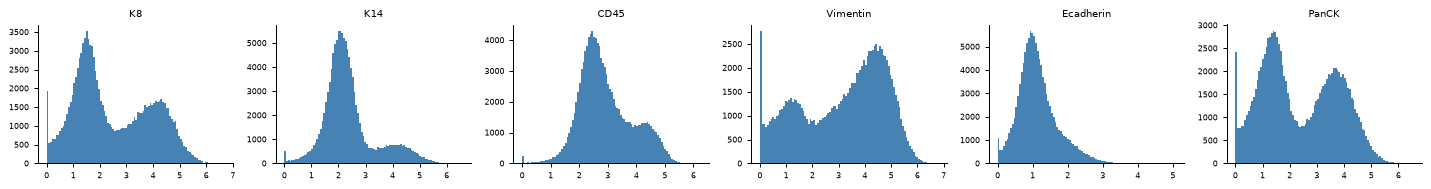

In [15]:
# 🖐️ INTERACTIF
COFACTOR = 150
EXCLUDE_PATTERN = r"^(DAPI|Blank|Empty)"

table = sdata.tables["table"]
MARKERS = [m for m in table.var_names if not re.match(EXCLUDE_PATTERN, m)]
print(len(MARKERS), "marqueurs :", MARKERS)
_layer = {"fcs": "raw", "mask_mean": "mask_mean", "mask_spillover": "mask_spillover"}[MEASUREMENT]
if _layer not in table.layers:
    raise ValueError(f"La mesure '{MEASUREMENT}' n'est pas disponible : exécutez la section 0.7 ou mettez MEASUREMENT = 'fcs'.")
print("Intensités utilisées :", MEASUREMENT)
raw = pd.DataFrame(np.asarray(table.layers[_layer]), columns=table.var_names, index=table.obs_names)
expr = np.arcsinh(raw[MARKERS] / COFACTOR).astype(np.float32)

fig, axes = plt.subplots(int(np.ceil(len(MARKERS) / 6)), 6, figsize=(16, 2.2 * np.ceil(len(MARKERS) / 6)), squeeze=False)
for ax, m in zip(axes.flat, MARKERS):
    ax.hist(expr[m], bins=100, color="steelblue"); ax.set_title(m, fontsize=8); ax.tick_params(labelsize=6)
for ax in axes.flat[len(MARKERS):]: ax.axis("off")
fig.tight_layout(); plt.show()

In [16]:
# Tableau de travail : une ligne par cellule (équivalent de fsApply(output$fcs1, exprs) + métadonnées)
obs = table.obs
cells = expr.copy()
for c in ["region_id", "cell_id", "x_px", "y_px", "size", "Area_px", "MajAxis_px", "MinAxis_px", "Eccentricity"]:
    if c in obs: cells[c] = obs[c].values
cells["sample_id"] = cells["region_id"].map(rmeta["sample_id"]).astype(str)
for short, src in [("SPC", "Case"), ("site", "Anno"), ("tumor", "Tumor"), ("type", "Phenotype"), ("met", "Met"), ("paired", "Paired")]:
    cells[short] = cells["region_id"].map(rmeta[src]).values
cells["site2"] = site2_of(cells["site"])
cells["X_um"], cells["Y_um"] = cells["x_px"] * PIXEL_SIZE_UM, cells["y_px"] * PIXEL_SIZE_UM
if "Area_px" in cells:
    cells["Area"] = cells["Area_px"] * PIXEL_SIZE_UM ** 2; cells["MajAxis"] = cells["MajAxis_px"] * PIXEL_SIZE_UM
else:
    cells["Area"] = cells["size"] * PIXEL_SIZE_UM ** 2
print(f"{len(cells):,} cellules, {cells['region_id'].nunique()} région(s)")

118,998 cellules, 1 région(s)


## 1.3 Diagnostics et clustering FlowSOM + métaclustering consensus

Comme `clusterfcs()` du R : grille SOM 10×10 puis métaclustering consensus hiérarchique (lien moyen, 100 rééchantillonnages à 90 %).

> 🖐️ **INTERACTIF** — `N_CLUSTERS` (50 dans le R ; avec ~25 marqueurs et une seule région, 20–30 suffisent souvent) et `CLUSTER_BY` (par défaut : tous les marqueurs retenus).

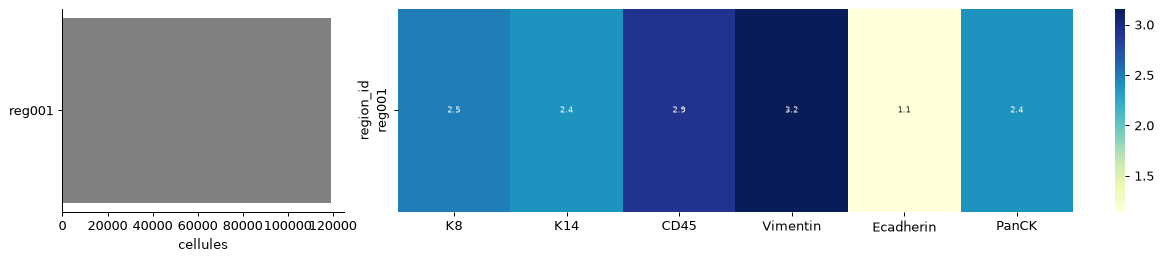

In [17]:
# 🔍 Diagnostics : cellules et expression moyenne par région
cnt = cells.groupby("region_id").size()
fig, axes = plt.subplots(1, 2, figsize=(14, max(3, 0.3 * len(cnt) + 2)), gridspec_kw=dict(width_ratios=[1, 3]))
axes[0].barh(cnt.index, cnt.values, color="grey"); axes[0].set_xlabel("cellules")
sns.heatmap(cells.groupby("region_id")[MARKERS].mean(), cmap="YlGnBu", ax=axes[1], annot=len(cnt) < 15, fmt=".1f", annot_kws={"size": 6})
fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "Diagnostics.pdf")); plt.show()

In [18]:
# 🖐️ INTERACTIF
N_CLUSTERS = 30
CLUSTER_BY = list(MARKERS)

from flowsom.models import FlowSOMEstimator
est = FlowSOMEstimator(xdim=10, ydim=10, rlen=10, n_clusters=N_CLUSTERS, seed=SEED)
cells["cell_clustering"] = est.fit_predict(cells[CLUSTER_BY].to_numpy(np.float32)).astype(int) + 1
print(cells["cell_clustering"].nunique(), "métaclusters")

30 métaclusters


## 1.4 Annotation des clusters

> 🖐️ **INTERACTIF — étape experte manuelle.** La heatmap (marqueurs normalisés 0–1 entre les quantiles 1 % et 99 %) et le tableau des marqueurs dominants servent à nommer chaque cluster. Une **suggestion automatique** est calculée par des règles simples (`ANNOTATION_RULES`) : elle sert de point de départ et doit être vérifiée.
> Corrigez avec l'éditeur (menus déroulants) → **Enregistrer** → relancez la cellule « Application de l'annotation ». L'annotation est sauvegardée dans `merge_phenocycler.xlsx` (même format que `merge.xlsx` : `original_cluster`, `new_cluster`) et rechargée aux exécutions suivantes.

,% cellules,suggestion,annotation actuelle,marqueurs dominants
1,2.79,CK8,CK8,"K8 0.81, PanCK 0.76, Ecadherin 0.65, CD45 0.40"
2,12.29,Str_V,Str_V,"Vimentin 0.76, Ecadherin 0.27, K14 0.26, CD45 ..."
3,2.80,CK8,CK8,"PanCK 0.87, K8 0.86, Vimentin 0.55, CD45 0.50"
4,6.74,Str_V,Str_V,"CD45 0.71, Vimentin 0.61, K14 0.33, Ecadherin ..."
5,2.87,CK14,CK14,"K14 0.80, PanCK 0.71, K8 0.67, Ecadherin 0.65"
6,1.28,Str_V,Str_V,"Vimentin 0.43, Ecadherin 0.32, K14 0.29, K8 0.26"
7,10.88,CK8,CK8,"K8 0.64, PanCK 0.64, CD45 0.31, K14 0.30"
8,1.34,Str_V,Str_V,"Vimentin 0.75, CD45 0.75, PanCK 0.63, K8 0.59"
9,3.26,CK8,CK8,"K8 0.69, PanCK 0.68, K14 0.46, Ecadherin 0.46"
10,4.59,Str_V,Str_V,"Vimentin 0.90, CD45 0.42, Ecadherin 0.42, K14 ..."


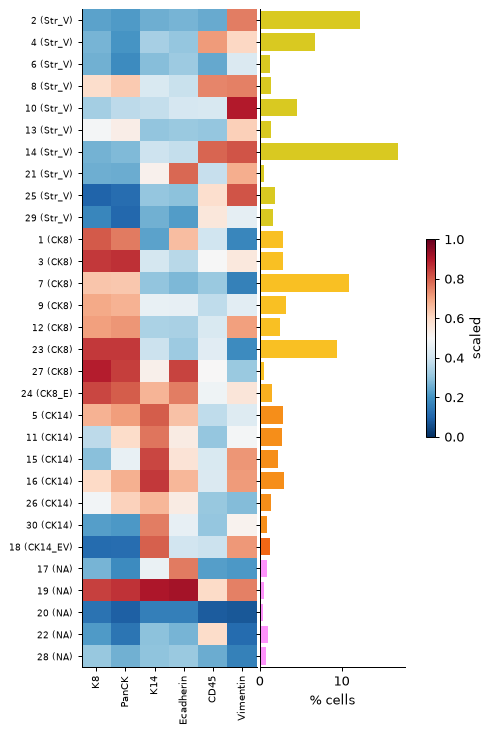

In [19]:
def scale01(df, cols):
    X = df[cols].to_numpy(float)
    lo, hi = np.nanquantile(X, 0.01, axis=0), np.nanquantile(X, 0.99, axis=0)
    return pd.DataFrame(np.clip((X - lo) / (hi - lo + 1e-12), 0, 1), columns=cols, index=df.index)

e01 = scale01(cells, CLUSTER_BY); e01["cl"] = cells["cell_clustering"].values
mean01 = e01.groupby("cl").mean()
zc = (mean01 - mean01.mean()) / mean01.std(ddof=1)
suggest = {}
for k, row in zc.iterrows():
    # score = z moyen des marqueurs requis − z moyen des autres marqueurs (pénalise les clusters « tout positif »)
    sc = {ct: row[[m for m in ms if m in row.index]].mean() - row.drop([m for m in ms if m in row.index]).mean()
          for ct, ms in ANNOTATION_RULES.items() if any(m in row.index for m in ms) and ct in CLUSTERLEVELS}
    best = max(sc, key=sc.get) if sc else "NA"
    suggest[k] = best if sc.get(best, -9) >= MIN_RULE_SCORE else "NA"

MERGE_FILE = os.path.join(OUT_DIR, "merge_phenocycler.xlsx")
if os.path.exists(MERGE_FILE):
    _m = pd.read_excel(MERGE_FILE, keep_default_na=False)
    current = dict(zip(_m["original_cluster"].astype(int), _m["new_cluster"].replace("", "NA").astype(str)))
    if set(current) != set(mean01.index):
        print("⚠️ merge_phenocycler.xlsx ne correspond plus aux clusters actuels → suggestions utilisées"); current = suggest
else:
    current = suggest

prop = cells["cell_clustering"].value_counts(normalize=True).sort_index() * 100
top = mean01.apply(lambda r: ", ".join(f"{m} {v:.2f}" for m, v in r.sort_values(ascending=False).head(4).items()), axis=1)
display(pd.DataFrame({"% cellules": prop.round(2), "suggestion": pd.Series(suggest), "annotation actuelle": pd.Series(current),
                      "marqueurs dominants": top}))

order = sorted(mean01.index, key=lambda k: (CLUSTERLEVELS.index(current[k]) if current[k] in CLUSTERLEVELS else 999, k))
m = mean01.loc[order]
cols = [m.columns[i] for i in leaves_list(linkage(m.T.values, "complete"))] if m.shape[1] > 2 else list(m.columns)
fig, (ax, axb) = plt.subplots(1, 2, figsize=(0.3 * len(cols) + 4, 0.25 * len(m) + 2), gridspec_kw=dict(width_ratios=[len(cols), 5], wspace=.02), sharey=True)
im = ax.imshow(m[cols].values, aspect="auto", cmap=RDBU_R, vmin=0, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(m))); ax.set_yticklabels([f"{k} ({current[k]})" for k in order], fontsize=7)
axb.barh(range(len(m)), prop.reindex(order).values, color=[COLORASSIGNED.get(current[k], "grey") for k in order])
axb.set_xlabel("% cells"); fig.colorbar(im, ax=[ax, axb], shrink=.3, label="scaled")
fig.savefig(os.path.join(OUT_DIR, "Clusteringheatmap_all.pdf"), bbox_inches="tight"); plt.show()

In [20]:
# 🖐️ INTERACTIF — éditeur d'annotation
try:
    import ipywidgets as widgets
    _dd = {k: widgets.Dropdown(options=CLUSTERLEVELS, value=current[k] if current[k] in CLUSTERLEVELS else "NA",
                               description=f"cl {k}", layout=widgets.Layout(width="200px")) for k in sorted(mean01.index)}
    _btn = widgets.Button(description="Enregistrer", button_style="success"); _out = widgets.Output()
    def _save(_):
        pd.DataFrame({"original_cluster": list(_dd), "new_cluster": [w.value for w in _dd.values()]}).to_excel(MERGE_FILE, index=False)
        with _out: print("Enregistré →", MERGE_FILE, "— relancez la cellule suivante.")
    _btn.on_click(_save)
    display(widgets.VBox([widgets.GridBox(list(_dd.values()), layout=widgets.Layout(grid_template_columns="repeat(5, 210px)")), _btn, _out]))
except ImportError:
    print("ipywidgets indisponible : éditez", MERGE_FILE)

In [21]:
# Application de l'annotation
if os.path.exists(MERGE_FILE):
    _m = pd.read_excel(MERGE_FILE, keep_default_na=False)
    mapping = dict(zip(_m["original_cluster"].astype(int), _m["new_cluster"].replace("", "NA").astype(str)))
else:
    mapping = current
    pd.DataFrame({"original_cluster": list(mapping), "new_cluster": list(mapping.values())}).to_excel(MERGE_FILE, index=False)
cells["cell_clustering1m"] = cells["cell_clustering"].map(mapping).fillna("NA").astype(str)
unknown = set(cells["cell_clustering1m"]) - set(CLUSTERLEVELS)
if unknown:
    print("⚠️ types absents de CLUSTERLEVELS, ajoutés à la fin :", unknown)
    CLUSTERLEVELS = CLUSTERLEVELS[:-1] + sorted(unknown) + ["NA"]; setup_levels()
display(cells["cell_clustering1m"].value_counts().to_frame("n").T)

cell_clustering1m,Str_V,CK8,CK14,NA,CK8_E,CK14_EV
n,57886,38285,15493,4053,1840,1441


## 1.5 Heatmap des types annotés et UMAP (`Clusteringheatmap_merged.pdf`, `Umaps.pdf`)

UMAP calculée avec `scanpy` sur au plus `UMAP_NCELLS` cellules par région (500 dans le R).

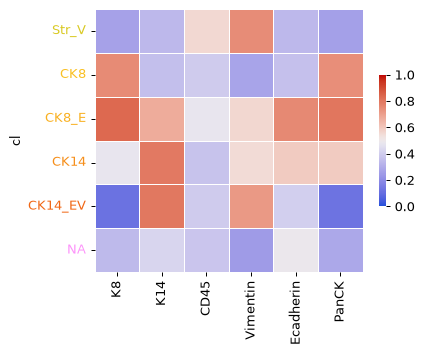

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Clusteringheatmap_merged.pdf


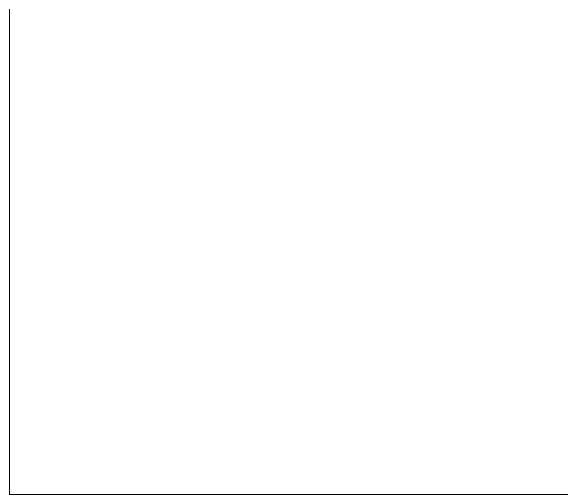

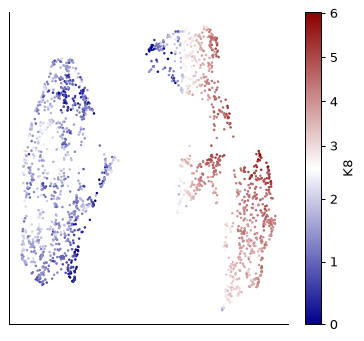

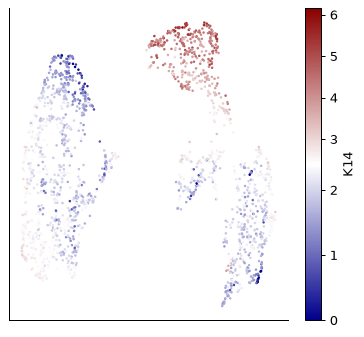

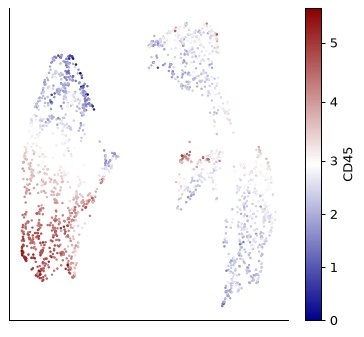

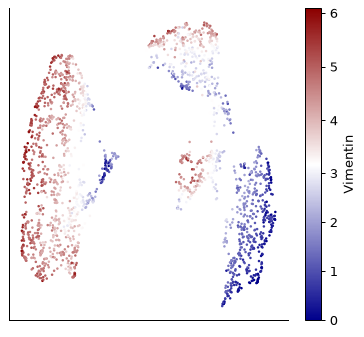

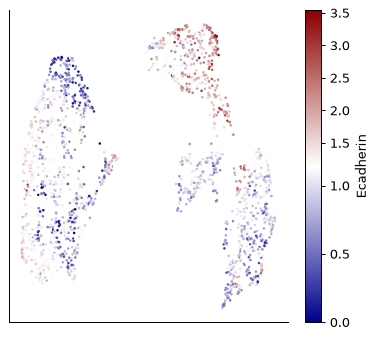

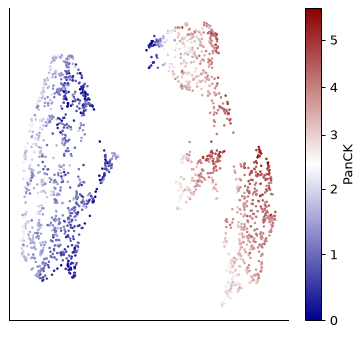

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Umaps.pdf


In [22]:
UMAP_NCELLS = 2000
e01 = scale01(cells, MARKERS); e01["cl"] = cells["cell_clustering1m"].values
hm = e01.groupby("cl").mean().reindex([c for c in CLUSTERLEVELS if c in set(e01["cl"])])
with FigPDF("Clusteringheatmap_merged.pdf") as pdf:
    fig, ax = plt.subplots(figsize=(0.3 * len(MARKERS) + 3, 0.3 * len(hm) + 2))
    sns.heatmap(hm, cmap=cc.cm["diverging_bwr_40_95_c42"], vmin=0, vmax=1, linewidths=.5, linecolor="white", ax=ax, cbar_kws={"shrink": .5})
    for t, c in zip(ax.get_yticklabels(), hm.index): t.set_color(COLORASSIGNED[c])
    pdf.add(fig)

import scanpy as sc
rng = np.random.default_rng(SEED)
idx = np.concatenate([rng.choice(ix, min(len(ix), UMAP_NCELLS), replace=False) for ix in cells.groupby("region_id").indices.values()])
idx = idx[~cells.iloc[idx][MARKERS].duplicated().to_numpy()]
um = ad.AnnData(cells.iloc[idx][MARKERS].to_numpy(np.float32), obs=cells.iloc[idx][["region_id", "cell_clustering1m", "type", "site"]].astype(str).reset_index(drop=True))
um.var_names = MARKERS
sc.pp.neighbors(um, n_neighbors=15, use_rep="X", random_state=SEED); sc.tl.umap(um, min_dist=0.1, random_state=SEED)
umapRes = pd.DataFrame(um.obsm["X_umap"], columns=["umap1", "umap2"]).join(um.obs).join(pd.DataFrame(um.X, columns=MARKERS))
umapRes = umapRes[umapRes["cell_clustering1m"] != "NA"]
with FigPDF("Umaps.pdf") as pdf:
    fig, ax = plt.subplots(figsize=(8, 7))
    for k, g in umapRes.groupby("cell_clustering1m"):
        ax.scatter(g["umap1"], g["umap2"], s=1, c=COLORASSIGNED.get(k, "grey"), label=k, rasterized=True)
    ax.legend(markerscale=6, fontsize=7, ncol=2, bbox_to_anchor=(1, 1), frameon=False); ax.set_xticks([]); ax.set_yticks([])
    pdf.add(fig)
    for mk in MARKERS:
        fig, ax = plt.subplots(figsize=(5, 4.5))
        v = umapRes[mk]
        s_ = ax.scatter(umapRes["umap1"], umapRes["umap2"], c=v, s=1, cmap=LinearSegmentedColormap.from_list("b", ["darkblue", "white", "darkred"]),
                        norm=matplotlib.colors.TwoSlopeNorm(vcenter=v.mean(), vmin=v.min() - 1e-6, vmax=v.max() + 1e-6), rasterized=True)
        fig.colorbar(s_, label=mk); ax.set_xticks([]); ax.set_yticks([]); pdf.add(fig)

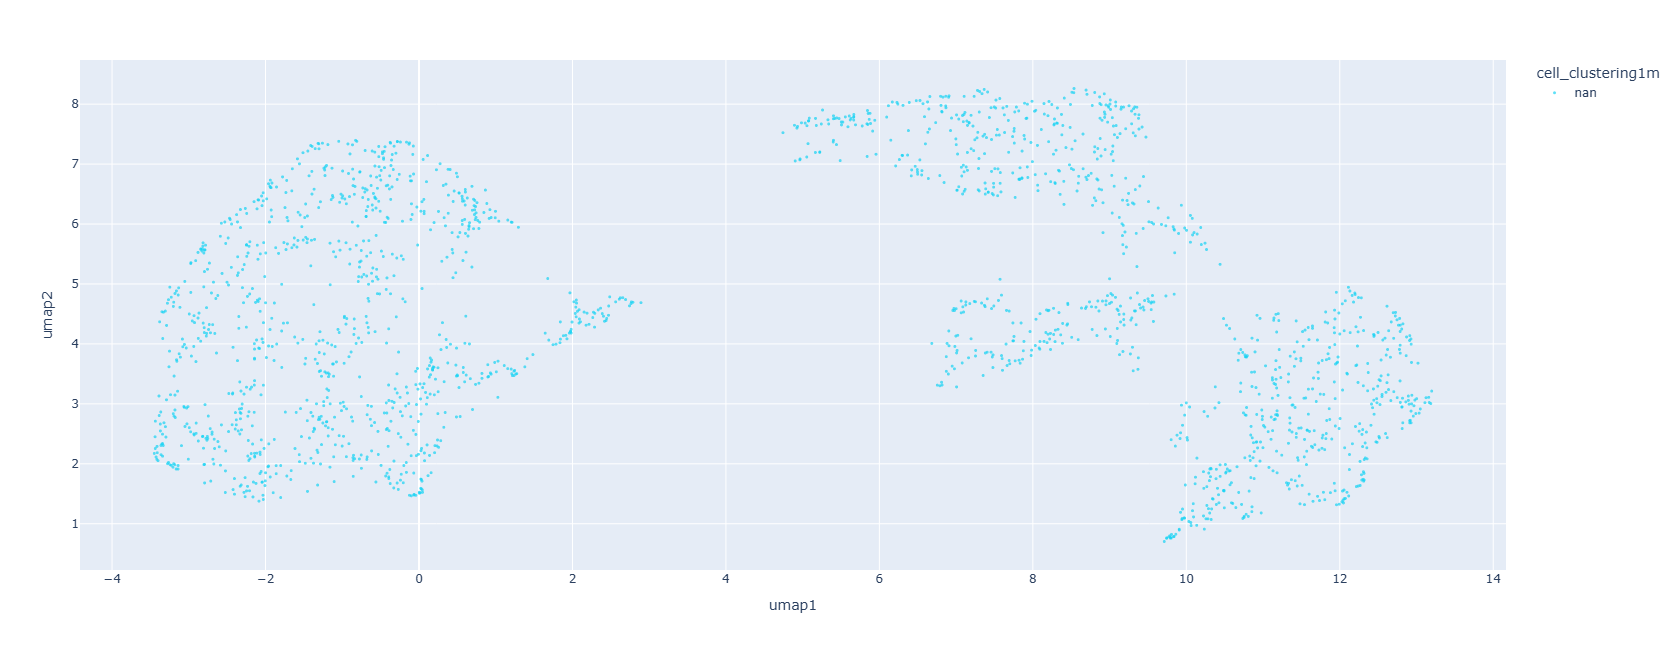

In [23]:
# 🖐️ INTERACTIF — UMAP interactive
UMAP_COLOR_BY = "cell_clustering1m"
figp = px.scatter(umapRes, x="umap1", y="umap2", color=UMAP_COLOR_BY, render_mode="webgl", height=650, opacity=.7,
                  color_discrete_map=COLORASSIGNED if UMAP_COLOR_BY == "cell_clustering1m" else None, hover_data=["region_id", "cell_clustering1m"])
figp.update_traces(marker=dict(size=3)); figp.write_html(os.path.join(OUT_DIR, "Umap_interactive.html")); figp.show()

## 1.6 Retour dans SpatialData et cartes spatiales des types cellulaires

Les annotations (`cell_type`, `cell_clustering`) et les intensités transformées sont ajoutées à la table de chaque région et **réécrites dans les Zarr** : `spatialdata-plot` peut alors colorer directement les cellules de la carte de labels (ou les cercles) par type.

> 🖐️ **INTERACTIF** — choisissez la région, le canal de fond et une fenêtre (en pixels ; `WIN_SIZE = 0` = région entière, affichée à partir de la pyramide basse résolution).

In [24]:
def push_to_tables():
    """Ajoute l'annotation à la table de chaque région (tous les canaux et toutes les couches sont conservés)."""
    for r, s in sdatas.items():
        t = s.tables["table"]
        sub = cells.loc[t.obs_names]
        for c in ["cell_clustering", "sample_id", "type", "site", "met"]:
            t.obs[c] = sub[c].astype(str).values
        cats = [c for c in CLUSTERLEVELS if c in set(sub["cell_clustering1m"])]
        t.obs["cell_type"] = pd.Categorical(sub["cell_clustering1m"].values, categories=cats)
        t.uns["cell_type_colors"] = [COLORASSIGNED[c] for c in cats]
        t.uns["measurement_used"] = MEASUREMENT
        write_table(s, t)
push_to_tables()
print("Tables mises à jour dans", ZARR_DIR)

Tables mises à jour dans D:\ELOISE\EXP112\ROI_9x7\spatialdata


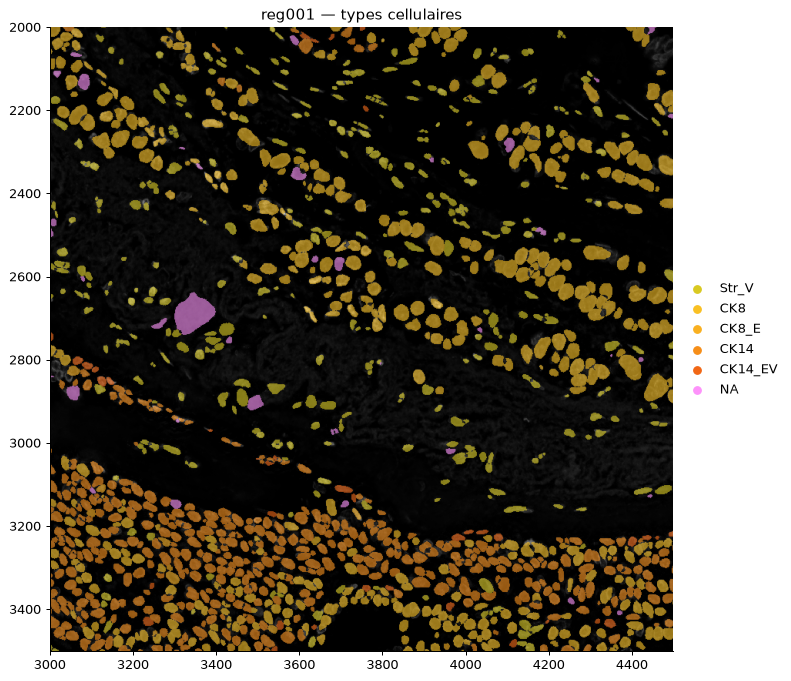

In [25]:
# 🖐️ INTERACTIF
MAP_REGION = REGIONS[0]
MAP_CHANNEL = "DAPI_cyc001"
WIN_X0, WIN_Y0, WIN_SIZE = 3000, 2000, 1500

s = sdatas[MAP_REGION]
pal = {c: COLORASSIGNED[c] for c in s.tables["table"].obs["cell_type"].cat.categories}
target = s.tables["table"].obs["element"].iloc[0]
view = s if WIN_SIZE == 0 else sd.bounding_box_query(s, axes=("x", "y"), min_coordinate=[WIN_X0, WIN_Y0],
                                                       max_coordinate=[WIN_X0 + WIN_SIZE, WIN_Y0 + WIN_SIZE], target_coordinate_system=MAP_REGION)
fig, ax = plt.subplots(figsize=(10, 9))
p = view.pl
if f"{MAP_REGION}_image" in view.images:
    chs = list(get_channel_names(view[f"{MAP_REGION}_image"]))
    p = p.render_images(f"{MAP_REGION}_image", channel=MAP_CHANNEL if MAP_CHANNEL in chs else chs[0], cmap="gray", colorbar=False).pl
if target.endswith("_labels"):
    p = p.render_labels(target, color="cell_type", table_name="table", palette=list(pal.values()), groups=list(pal.keys()), fill_alpha=.6).pl
else:
    p = p.render_shapes(target, color="cell_type", table_name="table", palette=list(pal.values()), groups=list(pal.keys())).pl
p.show(coordinate_systems=MAP_REGION, ax=ax, title=f"{MAP_REGION} — types cellulaires")
fig.savefig(os.path.join(OUT_DIR, f"Spatial_celltypes_{MAP_REGION}.pdf"), bbox_inches="tight"); plt.show()

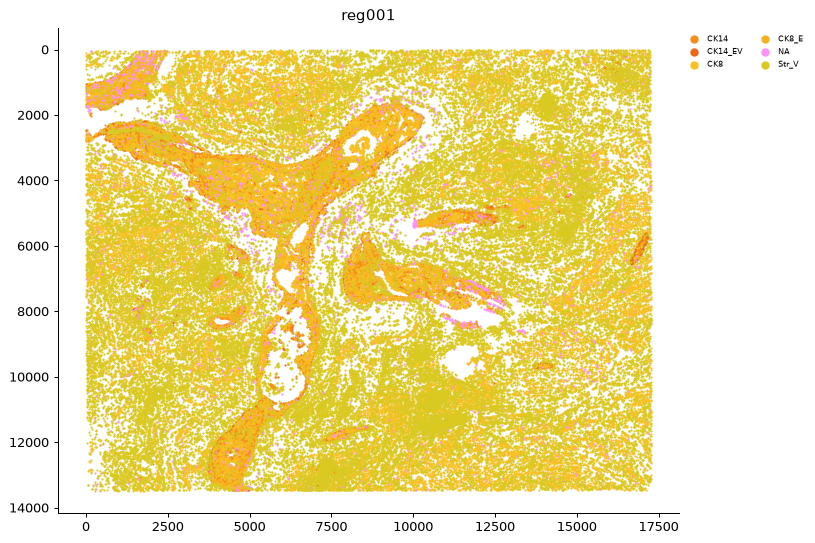

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Spatial_celltypes_all.pdf


In [26]:
# Vue d'ensemble de toutes les régions (centroïdes colorés par type) → Spatial_celltypes_all.pdf
with FigPDF("Spatial_celltypes_all.pdf") as pdf:
    for r, g in cells.groupby("region_id"):
        fig, ax = plt.subplots(figsize=(9, 7))
        for k, gg in g.groupby("cell_clustering1m"):
            ax.scatter(gg["x_px"], gg["y_px"], s=.5, c=COLORASSIGNED.get(k, "grey"), label=k, rasterized=True)
        ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_title(r)
        ax.legend(markerscale=8, fontsize=6, ncol=2, bbox_to_anchor=(1, 1), frameon=False)
        pdf.add(fig)

cells.to_parquet(os.path.join(OUT_DIR, "cells.parquet"))
save_state("state_part1.pkl", dict(MARKERS=MARKERS, CLUSTERLEVELS=CLUSTERLEVELS, rmeta=rmeta, HAS_GROUPS=HAS_GROUPS))

# Partie 2 — Abondances (`IMCpipeline_2.R`)

Les proportions sont calculées par échantillon (`sample_id` de `regions_metadata.xlsx`, une région par défaut). Les comparaisons LUM vs TNC et primaire vs métastase ne sont faites que si les métadonnées le permettent (`HAS_GROUPS`).

In [27]:
if "cells" not in globals() or "cell_clustering1m" not in cells:
    cells = pd.read_parquet(os.path.join(OUT_DIR, "cells.parquet"))
    globals().update(load_state("state_part1.pkl")); setup_levels()

def facet_axes(n, ncol, w=3, h=2.3):
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(w * ncol, h * nrow), squeeze=False)
    for ax in axes.flat[n:]: ax.axis("off")
    return fig, axes.flat

samp_meta = cells.groupby("sample_id")[["SPC", "type", "site", "site2", "met"]].first()
sample_cols = sorted(samp_meta.index)
counts = pd.crosstab(cells["cell_clustering1m"], cells["sample_id"]).reindex(columns=sample_cols, fill_value=0)
counts = counts.reindex([c for c in CLUSTERLEVELS if c in counts.index])
props = counts / counts.sum() * 100
counts_noNA = counts.drop(index="NA", errors="ignore"); props_noNA = counts_noNA / counts_noNA.sum() * 100
for n, d in [("Results_counts.csv", counts), ("Results_props.csv", props), ("Results_props_noNA.csv", props_noNA)]:
    d.to_csv(os.path.join(OUT_DIR, n))

def melt_props(p):
    g = p.rename_axis("cluster").reset_index().melt(id_vars="cluster", var_name="sample_id", value_name="proportion")
    g = g.join(samp_meta, on="sample_id")
    return g[g["type"].astype(str) != "CTRL"]

ggdf = melt_props(props_noNA)
display(props_noNA.round(2))

sample_id,reg001
cell_clustering1m,
Str_V,50.36
CK8,33.31
CK8_E,1.60
CK14,13.48
CK14_EV,1.25


## 2.1 Barres empilées (`Abundance_stackedbar_*.pdf`)

Échantillons ordonnés par % total de macrophages ; facettes par site (`site2`) et par sous-type si disponibles ; versions « toutes cellules », macrophages, stroma, lymphocytes.

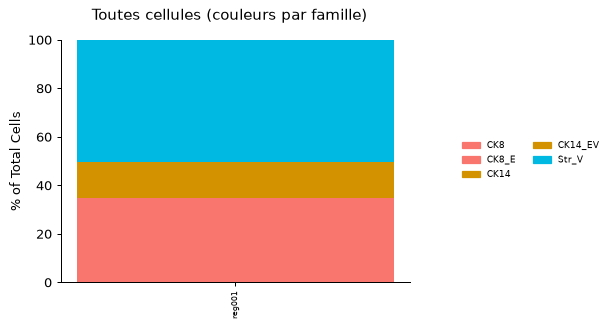

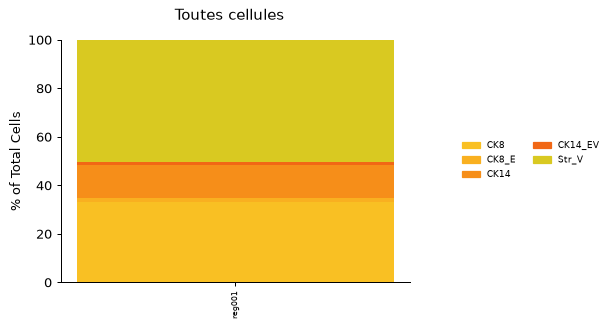

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Abundance_stackedbar_noNA.pdf


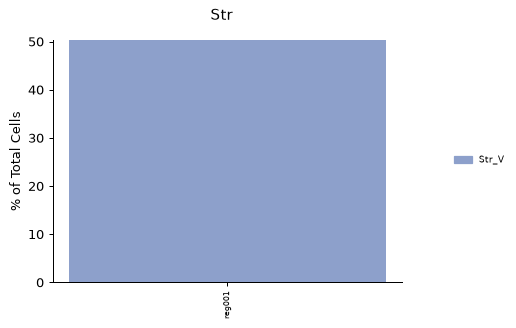

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Abundance_stackedbar_Str.pdf


In [28]:
def stacked_facets(df, x, y, fill, facet, x_order, fill_order, colors, title=None, legend=True, figsize=None, ylabel="% of Total Cells"):
    facets = ordered(df[facet], SITELEVELS + TYPELEVELS) if facet else ["all"]
    if facet is None:
        df = df.assign(_f="all"); facet = "_f"
    widths = [max(1, df.loc[df[facet].astype(str) == f, x].nunique()) for f in facets]
    fig, axes = plt.subplots(1, len(facets), figsize=figsize or (max(5, sum(widths) * .35 + 2), 3.5), sharey=True, squeeze=False,
                             gridspec_kw=dict(width_ratios=widths, wspace=.05))
    for ax, f in zip(axes[0], facets):
        piv = df[df[facet].astype(str) == f].pivot_table(index=x, columns=fill, values=y, aggfunc="sum", fill_value=0, observed=True)
        piv = piv.reindex([v for v in x_order if v in piv.index])
        bottom = np.zeros(len(piv))
        for c in fill_order:
            if c in piv:
                ax.bar(range(len(piv)), piv[c].values, bottom=bottom, color=colors[c], width=.85); bottom += piv[c].values
        ax.set_title(f if f != "all" else "", fontsize=8); ax.set_xticks(range(len(piv)))
        ax.set_xticklabels(piv.index, rotation=90, fontsize=6); ax.margins(y=0)
    axes[0][0].set_ylabel(ylabel)
    if title: fig.suptitle(title)
    if legend:
        fig.legend(handles=[Patch(color=colors[c], label=c) for c in fill_order if c in set(df[fill])], loc="center left",
                   bbox_to_anchor=(1, .5), fontsize=7, frameon=False, ncol=2 if len(fill_order) > 15 else 1)
    return fig

mac_tot = ggdf[ggdf["cluster"].isin(MAC_TYPES)].groupby("sample_id")["proportion"].sum().sort_values(ascending=False)
x_order = list(mac_tot.index) + [s for s in sample_cols if s not in mac_tot.index]
facets = ["site2", "type"] if HAS_GROUPS else [None]
with FigPDF("Abundance_stackedbar_noNA.pdf") as pdf:
    for fct in facets:
        pdf.add(stacked_facets(ggdf, "sample_id", "proportion", "cluster", fct, x_order, CLUSTERLEVELS_MACS, COLORASSIGNEDBROAD,
                               title="Toutes cellules (couleurs par famille)"))
        pdf.add(stacked_facets(ggdf, "sample_id", "proportion", "cluster", fct, x_order, CLUSTERLEVELS_MACS, COLORASSIGNED,
                               title="Toutes cellules"))
for lab, members, palname in [("Macs", MAC_TYPES, "Dark2"), ("Str", STR_TYPES, "Set2"), ("Lym", LYM_TYPES, "Dark2")]:
    sub = ggdf[ggdf["cluster"].isin(members)]
    if sub.empty: continue
    cols_ = dict(zip(members, sns.color_palette(palname, max(len(members), 3)).as_hex()))
    with FigPDF(f"Abundance_stackedbar_{lab}.pdf") as pdf:
        for fct in facets:
            pdf.add(stacked_facets(sub, "sample_id", "proportion", "cluster", fct, x_order, members, cols_, title=lab))

## 2.2 Comparaisons LUM vs TNC, primaire vs métastase (`Abundance_box.pdf`, `Abundance_lolli_*.pdf`, `Abundance_*_LvT.csv`)

Proportions au sein des cellules CK, stromales et « autres », moyennées par patient (`Case`) ; test de Wilcoxon LUM vs TNC (seuls les résultats significatifs sont affichés, comme `stat_compare_means(hide.ns = TRUE)`).

In [29]:
def props_within(mask_fn):
    ct = counts[[mask_fn(c) for c in counts.index]]
    ct = ct.loc[:, ct.sum() > 0]
    return ct / ct.sum() * 100

groups = {"CK": props_within(lambda c: "CK" in c), "Str": props_within(lambda c: c in STR_TYPES),
          "Other": props_within(lambda c: c not in CK_TYPES + STR_TYPES + ["NA", "Neuron"])}
if not HAS_GROUPS:
    print("⏭️  Pas de groupes LUM/TNC dans les métadonnées : comparaisons ignorées")
else:
    met_cols = dict(zip(["Primary", "Metastatic"], hue_pal(2)))
    with FigPDF("Abundance_boxes_lines.pdf") as pdf:
        for gname, p in groups.items():
            g = melt_props(p)
            g = g.groupby(["cluster", "SPC", "met", "type"], observed=True)["proportion"].mean().rename("avg").reset_index()
            g["met"] = np.where(g["met"].astype(int) == 1, "Metastatic", "Primary")
            cls = [c for c in CLUSTERLEVELS_MACS if c in set(g["cluster"])]
            fig, axes = facet_axes(len(cls), 6, 2.2, 2.2)
            for ax, cl in zip(axes, cls):
                d = g[(g["cluster"] == cl) & g["type"].isin(["LUM", "TNC"])]
                order = [t for t in ["LUM", "TNC"] if t in set(d["type"])]
                if not order: ax.axis("off"); continue
                sns.boxplot(data=d, x="type", y="avg", hue="met", order=order, hue_order=list(met_cols), palette=met_cols, ax=ax,
                            showfliers=False, linewidth=.5, legend=False)
                sns.stripplot(data=d, x="type", y="avg", hue="met", order=order, hue_order=list(met_cols), palette=met_cols,
                              dodge=True, size=2, ax=ax, legend=False)
                if len(order) == 2:
                    pv = wilcox(d.loc[d["type"] == "LUM", "avg"], d.loc[d["type"] == "TNC", "avg"])
                    if signif(pv) != "ns": ax.text(.5, .95, signif(pv), transform=ax.transAxes, ha="center", va="top")
                ax.set_title(cl, fontsize=8); ax.set_xlabel(""); ax.set_ylabel("")
            fig.supylabel(f"% {gname} cells"); fig.tight_layout(); pdf.add(fig)

    def lollipop(g, met, title, ax):
        avg = g[g["met"].astype(int) == met].groupby(["cluster", "type"])["proportion"].mean().unstack()
        if not {"LUM", "TNC"}.issubset(avg.columns): ax.set_title(title + " (données insuffisantes)"); return
        a = pd.DataFrame({"LUM": avg["LUM"], "TNC": -avg["TNC"]}).dropna(); a = a.assign(diff=a.sum(axis=1)).sort_values("diff")
        y = np.arange(len(a)); c2 = hue_pal(2)
        ax.hlines(y, a["TNC"], a["LUM"], color="grey"); ax.scatter(a["TNC"], y, color=c2[0], label="TNC", zorder=3)
        ax.scatter(a["LUM"], y, color=c2[1], label="LUM", zorder=3); ax.set_yticks(y); ax.set_yticklabels(a.index, fontsize=7)
        ax.set_xlabel("-TNC to +LUM"); ax.set_title(title, fontsize=9); ax.axvline(0, color="lightgrey", lw=.5)

    for fname, g, lab in [("Abundance_lolli_ck_subsetCK.pdf", melt_props(groups["CK"]), "CK+ Cell Types"),
                          ("Abundance_lolli_mac.pdf", ggdf[ggdf["cluster"].isin(MAC_TYPES)], "Macrophage Subtypes")]:
        with FigPDF(fname) as pdf:
            fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
            lollipop(g, 0, f"{lab} (Primary)", axes[0]); lollipop(g, 1, f"{lab} (Metastatic)", axes[1])
            axes[1].legend(frameon=False); fig.tight_layout(); pdf.add(fig)

    from statsmodels.stats.multitest import multipletests
    gck = melt_props(groups["CK"])
    for met, fname in [(0, "Abundance_primary_LvT.csv"), (1, "Abundance_met_LvT.csv")]:
        rows = []
        for cl, d in gck[gck["met"].astype(int) == met].groupby("cluster"):
            rows.append({"cluster": cl, "group1": "LUM", "group2": "TNC",
                         "p": wilcox(d.loc[d["type"] == "LUM", "proportion"], d.loc[d["type"] == "TNC", "proportion"])})
        r = pd.DataFrame(rows)
        if len(r):
            ok = r["p"].notna()
            if ok.any(): r.loc[ok, "p.adj"] = multipletests(r.loc[ok, "p"], method="holm")[1]
            r["p.signif"] = r["p"].map(signif); r["method"] = "Wilcoxon"
        r.to_csv(os.path.join(OUT_DIR, fname), index=False)

⏭️  Pas de groupes LUM/TNC dans les métadonnées : comparaisons ignorées


## 2.3 Morphologie cellulaire (`Cellgeometricfeatures*.pdf`)

Aire (µm²) et grand axe (µm) mesurés sur la carte de labels (`regionprops`) ; à défaut, aire = `size` du FCS.

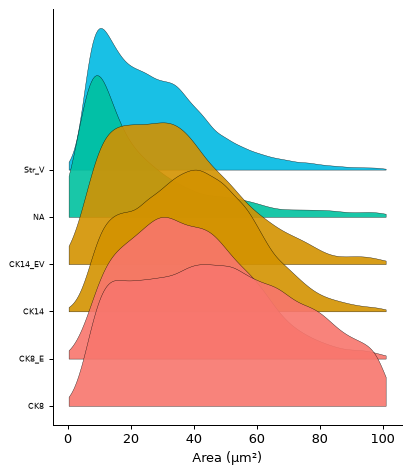

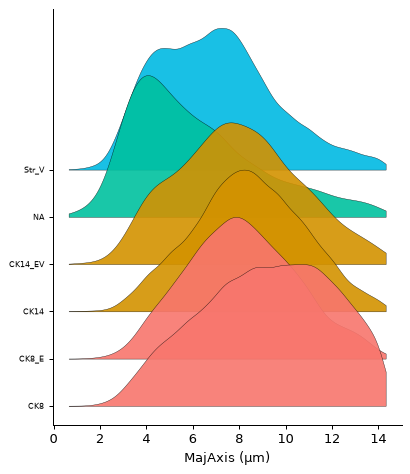

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Cellgeometricfeatures.pdf


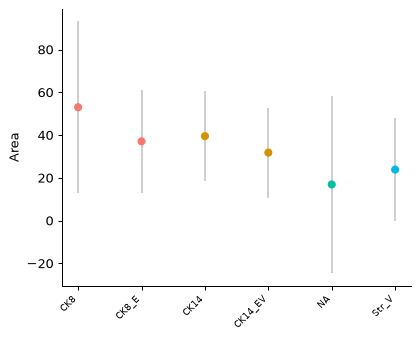

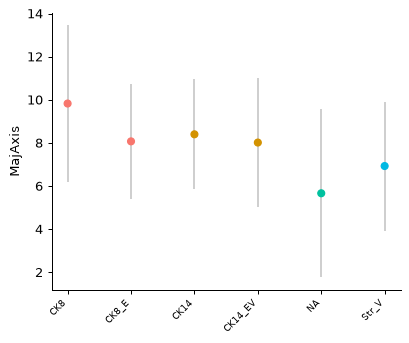

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Cellgeometricfeatures_dots.pdf


In [30]:
lv = [c for c in CLUSTERLEVELS_MACS if c in set(cells["cell_clustering1m"])]
geo_vars = [v for v in ["Area", "MajAxis"] if v in cells and cells[v].notna().any()]
with FigPDF("Cellgeometricfeatures.pdf") as pdf:
    for var in geo_vars:
        d = cells[["cell_clustering1m", var]].dropna(); cut = d[var].quantile(.95); d = d[d[var] < cut]
        xs = np.linspace(d[var].min(), cut, 200)
        fig, ax = plt.subplots(figsize=(5, 6))
        for i, cl in enumerate(lv):
            v = d.loc[d["cell_clustering1m"] == cl, var].to_numpy()
            if len(v) < 3 or np.std(v) == 0: continue
            k = stats.gaussian_kde(v)(xs); k = k / k.max() * 3
            ax.fill_between(xs, i, i + k, color=COLORASSIGNEDBROAD[cl], alpha=.9, lw=.3, ec="black", zorder=len(lv) - i)
        ax.set_yticks(range(len(lv))); ax.set_yticklabels(lv, fontsize=6); ax.set_xlabel(f"{var} ({'µm²' if var == 'Area' else 'µm'})")
        pdf.add(fig)
with FigPDF("Cellgeometricfeatures_dots.pdf") as pdf:
    for var in geo_vars:
        s_ = cells.groupby("cell_clustering1m")[var].agg(["median", "std"]).reindex(lv)
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.errorbar(range(len(lv)), s_["median"], yerr=s_["std"], fmt="none", ecolor="black", lw=.3)
        ax.scatter(range(len(lv)), s_["median"], c=[COLORASSIGNEDBROAD[c] for c in lv], s=30, zorder=3)
        ax.set_xticks(range(len(lv))); ax.set_xticklabels(lv, rotation=45, ha="right", fontsize=7); ax.set_ylabel(var)
        pdf.add(fig)

# Partie 3 — Heatmaps ciblées, corrélations, top 1-3 voisins (`IMCpipeline_3.R`)

## 3.1 Heatmaps ciblées et corrélations

> 🖐️ **INTERACTIF** — listes de marqueurs adaptées au panel PhenoCycler (CD86, ARG1, COL absents ; INOS, CD14, CD68, CD31 ajoutés).

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Clusterheatmap_focused_Mac.pdf


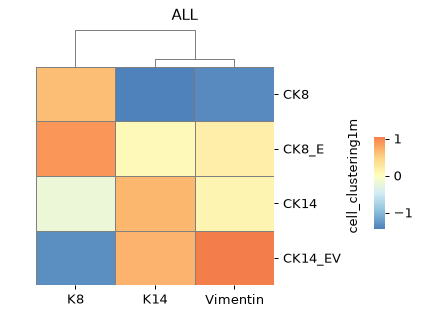

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Clusterheatmap_focused_CK.pdf
→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Clusterheatmap_focused_Str.pdf
→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Corr_mac.pdf


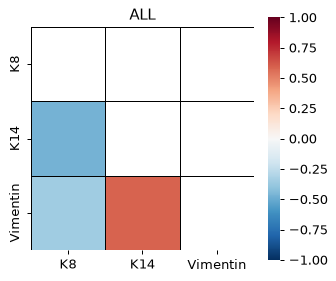

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Corr_ck.pdf


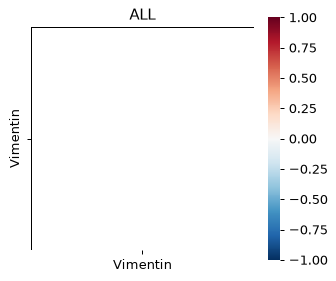

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Corr_str.pdf


In [31]:
# 🖐️ INTERACTIF
MARKERLIST_MAC = ["CD163", "CD206", "HLADR", "CD68", "CD14", "PDL1", "INOS"]
MARKERLIST_CK = ["K8", "K14", "Ecadh", "Vimentin", "Ki67", "HLADR"]
MARKERLIST_STR = ["Podoplanin", "Vimentin", "SMA", "CD31", "HLADR"]
MARKERLIST_MAC, MARKERLIST_CK, MARKERLIST_STR = ([m for m in l if m in cells] for l in (MARKERLIST_MAC, MARKERLIST_CK, MARKERLIST_STR))
PH_CMAP = LinearSegmentedColormap.from_list("ph", sns.color_palette("RdYlBu", 7)[::-1])
subsets = [("ALL", np.ones(len(cells), bool))] + ([("LUM", (cells["type"] == "LUM").values), ("TNC", (cells["type"] == "TNC").values)] if HAS_GROUPS else [])

for fname, ml, members in [("Clusterheatmap_focused_Mac.pdf", MARKERLIST_MAC, MAC_TYPES),
                           ("Clusterheatmap_focused_CK.pdf", MARKERLIST_CK, CK_TYPES),
                           ("Clusterheatmap_focused_Str.pdf", MARKERLIST_STR, STR_TYPES)]:
    with FigPDF(fname) as pdf:
        for lab, mask in subsets:
            m = cells.loc[mask].groupby("cell_clustering1m")[ml].mean().reindex(members).dropna(how="all")
            if len(m) < 2: continue
            z = ((m - m.mean()) / m.std(ddof=1)).fillna(0)
            g = sns.clustermap(z, row_cluster=False, col_cluster=len(ml) > 2, cmap=PH_CMAP, center=0, linewidths=.5, linecolor="grey",
                               figsize=(.4 * len(ml) + 3, .35 * len(z) + 2), dendrogram_ratio=(.1, .15), cbar_pos=(1.0, .3, .03, .3))
            g.fig.suptitle(lab, y=1.02); pdf.add(g.fig)

majortype = cells["cell_clustering1m"].map(lambda c: "Mac" if c in MAC_TYPES else "CK" if c in CK_TYPES else "Str" if c in STR_TYPES else c).values
for fname, mt, ml in [("Corr_mac.pdf", "Mac", MARKERLIST_MAC), ("Corr_ck.pdf", "CK", MARKERLIST_CK), ("Corr_str.pdf", "Str", MARKERLIST_STR)]:
    with FigPDF(fname) as pdf:
        for lab, mask in subsets:
            mm = mask & (majortype == mt)
            if mm.sum() < 3: continue
            C = cells.loc[mm, ml].corr()
            fig, ax = plt.subplots(figsize=(4, 3.5))
            sns.heatmap(C, mask=np.triu(np.ones_like(C, bool)), cmap=RDBU_R, vmin=-1, vmax=1, square=True, linewidths=.5, linecolor="black", ax=ax)
            ax.set_title(lab); pdf.add(fig)

## 3.2 Top 1-3 voisins des cellules CK+ (`NN_*_N1-3_Mac.pdf`, `Results_NN*.csv`)

⚠️ **DIFFÉRENCE** — le FCS PhenoCycler ne fournit pas `NN1..NN3` : les 3 plus proches voisins de chaque cellule sont recalculés **par région** à partir des centroïdes (`cKDTree`, distance euclidienne en µm).

Valeur = nombre de voisins de chaque type (`IMMUNECELLS`) pour 10 000 cellules CK du type indiqué, par condition (`sous-type_pri/met_site` si métadonnées, sinon échantillon).

> 🖐️ **INTERACTIF** — `IMMUNECELLS`, `INDEX_TYPES` (cellules CK de départ), `MIN_CELLS_CONDITION` (le R utilisait 1000 pour les métastases par organe ; 200 par défaut ici, une région PhenoCycler comptant ~10⁴–10⁵ cellules).

In [33]:
# 🖐️ INTERACTIF
IMMUNECELLS = list(MAC_TYPES)            # p. ex. ["Tc", "Th", "Treg", "B"] pour les lymphocytes
INDEX_TYPES = [c for c in CK_TYPES if c in set(cells["cell_clustering1m"])]
MIN_CELLS_CONDITION = 200

nn_type = np.empty((len(cells), 3), dtype=object)
for r, ix in cells.groupby("region_id").indices.items():
    xy = cells.iloc[ix][["X_um", "Y_um"]].to_numpy()
    _, nb = cKDTree(xy).query(xy, k=min(4, len(ix)))
    lab = cells["cell_clustering1m"].to_numpy()[ix]
    for k in range(1, nb.shape[1]):
        nn_type[ix, k - 1] = lab[nb[:, k]]
for k in range(3):
    cells[f"N{k+1}type"] = nn_type[:, k]

cells["condition"] = (cells["type"].astype(str) + "_" + np.where(cells["met"].astype(int) == 1, "met", "pri") + "_" + cells["site2"].astype(str)) \
    if HAS_GROUPS else cells["sample_id"].astype(str)
NN = cells[cells["cell_clustering1m"] != "NA"]

def nn_matrix(NN, objtypes):
    out, ann = {}, []
    for (obj, cond), d in NN[NN["cell_clustering1m"].isin(objtypes)].groupby(["cell_clustering1m", "condition"]):
        if len(d) < MIN_CELLS_CONDITION: continue
        name = f"{obj}_{cond}"
        out[name] = [(d[f"N{k}type"] == im).sum() / len(d) * 10000 for k in (1, 2, 3) for im in IMMUNECELLS]
        ann.append(dict(name=name, **{m.lower(): d[m].mean() for m in ["Vimentin", "Ecadh", "K8", "K14"] if m in d},
                        met="MET" if "_met_" in cond else "PRI", site=cond.split("_")[-1], type=cond.split("_")[0]))
    mat = pd.DataFrame(out, index=[f"N{k}_{im}" for k in (1, 2, 3) for im in IMMUNECELLS])
    return mat[mat.sum(axis=1) != 0], pd.DataFrame(ann).set_index("name") if ann else pd.DataFrame()

def nn_heatmap(mat, an, title, fname):
    if mat.shape[0] < 2 or mat.shape[1] < 2:
        print(f"{fname} : matrice trop petite {mat.shape} (baissez MIN_CELLS_CONDITION ?)"); return
    z = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1, ddof=1).replace(0, np.nan), axis=0).fillna(0)
    yb = [to_hex(c) for c in LinearSegmentedColormap.from_list("", ["black", "yellow"])(np.linspace(0, 1, 100))]
    bg = [to_hex(c) for c in LinearSegmentedColormap.from_list("", ["black", "green"])(np.linspace(0, 1, 100))]
    bc = [to_hex(c) for c in LinearSegmentedColormap.from_list("", ["black", "cyan"])(np.linspace(0, 1, 100))]
    an = an.reindex(z.columns); colc = pd.DataFrame(index=z.columns)
    for col, pal in [("vimentin", yb), ("ecadh", yb), ("k8", bg), ("k14", bc)]:
        if col in an: colc[col] = num2col(an[col].fillna(0), pal)
    colc["met"] = an["met"].map({"PRI": "black", "MET": "lightgray"})
    sites = ordered(an["site"], SITELEVELS); colc["site"] = an["site"].map(dict(zip(sites, sns.color_palette("Set1", max(3, len(sites))).as_hex())))
    g = sns.clustermap(z, cmap=RDBU_R, center=0, col_colors=colc, xticklabels=True, yticklabels=True,
                       figsize=(3 + .25 * z.shape[1], 3 + .3 * z.shape[0]), dendrogram_ratio=(.05, .08), cbar_pos=(1.02, .3, .02, .25))
    k = fcluster(g.dendrogram_row.linkage, t=min(4, z.shape[0]), criterion="maxclust")[g.dendrogram_row.reordered_ind]
    for i in np.where(np.diff(k) != 0)[0]: g.ax_heatmap.axhline(i + 1, color="white", lw=3)
    g.ax_heatmap.tick_params(axis="x", labelsize=6); g.fig.suptitle(title, y=1.02)
    with FigPDF(fname) as pdf: pdf.add(g.fig)

sets = [("LUM", NN[NN["type"] == "LUM"]), ("TNC", NN[NN["type"] == "TNC"])] if HAS_GROUPS else [("all", NN)]
for lab, d in sets:
    mat, an = nn_matrix(d, INDEX_TYPES)
    mat.to_csv(os.path.join(OUT_DIR, f"NN_{lab}_N1-3_matrix.csv"))
    nn_heatmap(mat, an, f"Top {'/'.join(IMMUNECELLS[:2])}… neighbors of CK+ clusters — {lab}", f"NN_{lab}_N1-3_Mac.pdf")

# Résumé par patient : voisins macrophages (N1..N3) des cellules CK primaires
by = "SPC" if HAS_GROUPS else "sample_id"
ck = NN[NN["cell_clustering1m"].isin(INDEX_TYPES) & ((NN["met"].astype(int) == 0) if HAS_GROUPS else True)]
parts = [ck[ck[f"N{k}type"].isin(IMMUNECELLS)].groupby([by, f"N{k}type"]).size().rename("Ntot").reset_index().rename(columns={f"N{k}type": "Ntype"}) for k in (1, 2, 3)]
top3 = pd.concat(parts).groupby([by, "Ntype"])["Ntot"].sum().reset_index()
top3["tot"] = top3[by].map(ck.groupby(by).size()); top3["normtot"] = top3["Ntot"] / top3["tot"] * 100
top3["median"] = top3.groupby("Ntype")["normtot"].transform("median"); top3["bins"] = (top3["normtot"] > top3["median"]).astype(int)
top3.to_csv(os.path.join(OUT_DIR, "Results_NN_pCKtoMac_by_patient.csv"), index=False)
display(top3.head())

NN_all_N1-3_Mac.pdf : matrice trop petite (0, 4) (baissez MIN_CELLS_CONDITION ?)


,sample_id,Ntype,Ntot,tot,normtot,median,bins


# Partie 4 — Relations de distance (`IMCpipeline_4.R`)

## 4.1 Composition et types rares

Pourcentage de chaque type par groupe (`LUM`/`TNC` si métadonnées, sinon toutes régions). Les types < 0,01 % et `NA` sont exclus des matrices de distance, comme dans le R.

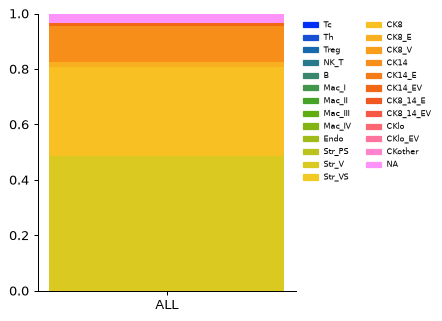

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Abundance_stackedbar_type.pdf
exclus : {'ALL': ['ctype25']}


In [34]:
cells["group"] = cells["type"].astype(str) if HAS_GROUPS else "ALL"
GROUPS = [g for g in (["LUM", "TNC"] if HAS_GROUPS else ["ALL"]) if g in set(cells["group"])]
pct = {g: cells[cells["group"] == g]["cell_clustering1m"].value_counts(normalize=True) * 100 for g in GROUPS}
excl = {g: sorted({f"ctype{CT2NUM[c]}" for c, v in p.items() if v < 0.01} | {f"ctype{CT2NUM['NA']}"}) for g, p in pct.items()}
pd.DataFrame(pct).reindex(CLUSTERLEVELS).round(3).to_csv(os.path.join(OUT_DIR, "Totalcounts_pct_by_group.csv"))
with FigPDF("Abundance_stackedbar_type.pdf") as pdf:
    fig, ax = plt.subplots(figsize=(1.2 * len(GROUPS) + 2.5, 4))
    for i, g in enumerate(GROUPS):
        b = 0
        for c in CLUSTERLEVELS:
            v = pct[g].get(c, 0) / 100; ax.bar(i, v, bottom=b, color=COLORASSIGNED[c], width=.8); b += v
    ax.set_xticks(range(len(GROUPS))); ax.set_xticklabels(GROUPS); ax.margins(y=0)
    ax.legend(handles=[Patch(color=COLORASSIGNED[c], label=c) for c in CLUSTERLEVELS], ncol=2, fontsize=6, bbox_to_anchor=(1, 1), frameon=False)
    pdf.add(fig)
print("exclus :", excl)

## 4.2 Distance au plus proche voisin de chaque type (équivalent de `spatstat::nndist(X, by = marks(X))`)

Pour chaque cellule (cluster ≠ NA), distance (µm) à la cellule la plus proche de chaque type **dans la même région**, la cellule elle-même exclue ; distances nulles ou infinies → `NaN`.

In [35]:
def nn_dist_by_type(xy, lab):
    out = np.full((len(xy), len(CLUSTERLEVELS)), np.nan, dtype=np.float32)
    for j, ct in enumerate(CLUSTERLEVELS):
        m = lab == ct; n = m.sum()
        if n == 0: continue
        d, _ = cKDTree(xy[m]).query(xy, k=min(2, n)); d = d.reshape(len(xy), -1)
        col = d[:, 0].copy(); col[m] = d[m, 1] if n > 1 else np.inf
        out[:, j] = col
    out[~np.isfinite(out) | (out == 0)] = np.nan
    return out

expr0 = cells[cells["cell_clustering1m"] != "NA"].copy()
D = np.full((len(expr0), len(CLUSTERLEVELS)), np.nan, dtype=np.float32)
for r, ix in expr0.groupby("region_id").indices.items():
    D[ix] = nn_dist_by_type(expr0.iloc[ix][["X_um", "Y_um"]].to_numpy(), expr0.iloc[ix]["cell_clustering1m"].to_numpy())
dist = pd.DataFrame(D, columns=CTYPE_COLS, index=expr0.index)
combined = pd.concat([expr0, dist], axis=1)
combined["ctype"] = "ctype" + combined["cell_clustering1m"].map(CT2NUM).astype(str)

def dist_matrix(df, exclude):
    m = df.set_index("ctype")[CTYPE_COLS]
    m = m.loc[:, m.sum(skipna=True) != 0]
    return m.loc[~m.index.isin(exclude), [c for c in m.columns if c not in exclude]]

mats = {}
for g in GROUPS:
    sub = combined[combined["group"] == g]
    mats[g] = dist_matrix(sub, excl[g])
    if HAS_GROUPS:
        mats[f"{g}pri"] = dist_matrix(sub[sub["met"].astype(int) == 0], excl[g])
        mats[f"{g}met"] = dist_matrix(sub[sub["met"].astype(int) == 1], excl[g])
for k, v in mats.items():
    v.reset_index().to_parquet(os.path.join(OUT_DIR, f"dist_{k}.parquet")); print(k, v.shape)
save_state("state_part4.pkl", dict(pct=pct, excl=excl, GROUPS=GROUPS))

ALL (114945, 5)


## 4.3 Carte de proximité dans SpatialData

Exemple d'utilisation directe de la table SpatialData : la distance de chaque cellule au macrophage le plus proche est ajoutée à `table.obs` puis affichée sur la carte de labels.

> 🖐️ **INTERACTIF** — région, type cible, fenêtre.

WARNING  render_labels: Column 'dist_nearest_Mac_I_Mac_II_Mac_III_Mac_IV_um' for element 'reg001_labels' contains  
         only NaN values; rendering with na_color.                                                                 


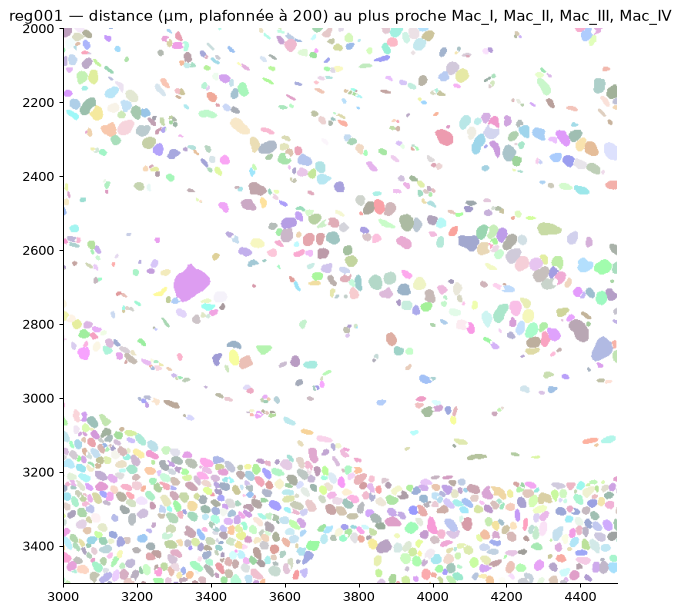

In [36]:
# 🖐️ INTERACTIF
PROX_REGION = REGIONS[0]
PROX_TARGETS = list(MAC_TYPES)
PX0, PY0, PSIZE = 3000, 2000, 1500

colname = "dist_nearest_" + "_".join(PROX_TARGETS)[:30] + "_um"
dd = combined[[f"ctype{CT2NUM[t]}" for t in PROX_TARGETS if t in CT2NUM]].min(axis=1)
s = sdatas[PROX_REGION]; t = s.tables["table"]
t.obs[colname] = dd.reindex(t.obs_names).clip(upper=200).values
target = str(t.obs["element"].iloc[0])
view = sd.bounding_box_query(s, axes=("x", "y"), min_coordinate=[PX0, PY0], max_coordinate=[PX0 + PSIZE, PY0 + PSIZE], target_coordinate_system=PROX_REGION)
fig, ax = plt.subplots(figsize=(9, 8))
render = view.pl.render_labels if target.endswith("_labels") else view.pl.render_shapes
render(target, color=colname, table_name="table", cmap="viridis_r").pl.show(coordinate_systems=PROX_REGION, ax=ax,
       title=f"{PROX_REGION} — distance (µm, plafonnée à 200) au plus proche {', '.join(PROX_TARGETS)}")
fig.savefig(os.path.join(OUT_DIR, f"Proximity_map_{PROX_REGION}.pdf"), bbox_inches="tight"); plt.show()

## 4.4 Proximité des macrophages selon le phénotype des cellules CK+ (surfaces 3D, `Distance_3DVE_*.pdf`)

Proximité = 1 / distance (µm⁻¹) au plus proche macrophage de chaque sous-type, interpolée sur une grille 40×40 dans le plan de deux marqueurs (équivalent `akima::interp`). Paires de marqueurs du R : ECAD/VIM → `Ecadh`/`Vimentin`, CK8/CK14 → `K8`/`K14`, VIM/CK14 → `Vimentin`/`K14`.

In [37]:
def akima_interp(x, y, z, n=40):
    d = pd.DataFrame({"x": x, "y": y, "z": z}).replace([np.inf, -np.inf], np.nan).dropna().groupby(["x", "y"], as_index=False)["z"].mean()
    XI, YI = np.meshgrid(np.linspace(d["x"].min(), d["x"].max(), n), np.linspace(d["y"].min(), d["y"].max(), n), indexing="ij")
    return XI, YI, griddata((d["x"], d["y"]), d["z"], (XI, YI), method="linear")

CMAP3D = ListedColormap([COOLWARM[i] for i in list(range(0, 57, 3)) + list(range(59, 100))])
MAC_CT = {m: f"ctype{CT2NUM[m]}" for m in MAC_TYPES if m in set(cells["cell_clustering1m"])}
CK_CELLS = combined[combined["cell_clustering1m"].isin(CK_TYPES)]
PAIRS = [(a, b) for a, b in [("Ecadh", "Vimentin"), ("K8", "K14"), ("Vimentin", "K14")] if a in cells and b in cells]
ZMAX = 0.16   # 🖐️ échelle z (µm⁻¹), comme le R (pixel IMC = 1 µm)

for g in GROUPS:
    df = CK_CELLS[CK_CELLS["group"] == g]
    for xm, ym in PAIRS:
        with FigPDF(f"Distance_3D_{g}_{xm}_{ym}.pdf") as pdf:
            for mac, ct in MAC_CT.items():
                sub = df[df[ct].notna()]
                if len(sub) < 10: continue
                XI, YI, ZI = akima_interp(sub[xm], sub[ym], 1 / sub[ct])
                fig = plt.figure(figsize=(5, 5)); ax = fig.add_subplot(projection="3d")
                sf = ax.plot_surface(XI, YI, np.clip(ZI, 0, ZMAX), cmap=CMAP3D, vmin=0, vmax=ZMAX, edgecolor="none")
                ax.set_zlim(0, ZMAX); ax.view_init(elev=40, azim=-30)
                ax.set_xlabel(xm); ax.set_ylabel(ym); ax.set_zlabel("proximity"); ax.set_title(f"{g}: CK+ to {mac}")
                fig.colorbar(sf, shrink=.5); pdf.add(fig)

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Distance_3D_ALL_K8_K14.pdf
→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Distance_3D_ALL_Vimentin_K14.pdf


In [38]:
# 🖐️ INTERACTIF — surface 3D manipulable
SURF_GROUP = GROUPS[0]
SURF_MAC = MAC_TYPES[0] if MAC_TYPES else None
SURF_X, SURF_Y = PAIRS[0] if PAIRS else (None, None)
if SURF_MAC and SURF_X:
    _s = CK_CELLS[(CK_CELLS["group"] == SURF_GROUP) & CK_CELLS[MAC_CT[SURF_MAC]].notna()]
    XI, YI, ZI = akima_interp(_s[SURF_X], _s[SURF_Y], 1 / _s[MAC_CT[SURF_MAC]])
    figp = go.Figure(go.Surface(x=XI, y=YI, z=ZI, colorscale="RdBu_r"))
    figp.update_layout(title=f"{SURF_GROUP}: CK+ to {SURF_MAC}", height=650, scene=dict(xaxis_title=SURF_X, yaxis_title=SURF_Y, zaxis_title="1/µm"))
    figp.write_html(os.path.join(OUT_DIR, "Distance_3D_interactive.html")); figp.show()

KeyError: 'Mac_I'

## 4.5 Expression des CK+ proches (< seuil) vs éloignées d'un macrophage (`Expression_byProximity.pdf`)

Moyennes de Vimentin, Ki67, HLADR par patient (`Case`) et site ; test t apparié close vs far (seuls les résultats significatifs sont affichés). Sans métadonnées, un point par région.

> 🖐️ **INTERACTIF** — `DIST_THRESHOLD_UM` (50 dans le R).

In [ ]:
# 🖐️ INTERACTIF
DIST_THRESHOLD_UM = 50
YVARS = [v for v in ["Ki67", "Vimentin", "HLADR"] if v in cells]
unit = "SPC" if HAS_GROUPS else "region_id"
rows = []
for mac, ct in MAC_CT.items():
    sub = CK_CELLS[CK_CELLS[ct].notna()]
    for prox, s_ in [("close", sub[sub[ct] < DIST_THRESHOLD_UM]), ("far", sub[sub[ct] >= DIST_THRESHOLD_UM])]:
        a = s_.groupby([unit, "site2", "group"])[YVARS].mean().reset_index(); a["mac"], a["prox"] = mac, prox; rows.append(a)
dfallmac = pd.concat(rows) if rows else pd.DataFrame()
dfallmac.to_csv(os.path.join(OUT_DIR, "Results_ExpressionbyProximity.csv"), index=False)

if len(dfallmac):
    sites = ordered(dfallmac["site2"], SITELEVELS); tpal = dict(zip(GROUPS, hue_pal(len(GROUPS))))
    with FigPDF("Expression_byProximity.pdf") as pdf:
        for y in YVARS:
            fig, axes = plt.subplots(len(sites), len(MAC_CT), figsize=(1.5 * len(MAC_CT) + 1, 1.4 * len(sites) + .8), squeeze=False)
            for i, st in enumerate(sites):
                for j, mac in enumerate(MAC_CT):
                    ax = axes[i][j]; d = dfallmac[(dfallmac["site2"] == st) & (dfallmac["mac"] == mac)]
                    w = d.pivot_table(index=[unit, "group"], columns="prox", values=y)
                    for (u, g), r in w.iterrows():
                        ax.plot([0, 1], [r.get("close", np.nan), r.get("far", np.nan)], marker="o", ms=2, lw=.7, color=tpal.get(g, "grey"))
                    if {"close", "far"}.issubset(w.columns) and len(w.dropna()) > 1:
                        pv = stats.ttest_rel(w.dropna()["close"], w.dropna()["far"]).pvalue
                        if signif(pv) != "ns": ax.text(.5, .95, signif(pv), transform=ax.transAxes, ha="center", va="top")
                    ax.set_xticks([0, 1]); ax.set_xticklabels(["close", "far"] if i == len(sites) - 1 else [], fontsize=7)
                    ax.tick_params(labelsize=6); ax.margins(x=.3, y=.25)
                    if i == 0: ax.set_title(mac, fontsize=8)
                    if j == len(MAC_CT) - 1: ax.yaxis.set_label_position("right"); ax.set_ylabel(st, fontsize=8)
            fig.suptitle(y); fig.legend(handles=[Patch(color=c, label=k) for k, c in tpal.items()], loc="upper right", frameon=False)
            fig.tight_layout(); pdf.add(fig)

## 4.6 Distance moyenne des cellules CK+ aux autres types (`Distance_MeanCKtoTME_*.pdf`)

> 🖐️ **INTERACTIF** — dans le R il fallait éditer `subsetdf_distCK` à la main ; ici une heatmap est produite pour chaque sous-ensemble (groupe × primaire/métastase, ou région).

In [ ]:
non_ck = [c for c in CLUSTERLEVELS if c not in CK_TYPES and c not in ("NA", "Neuron")]
subsets = ({f"{g} {'PRI' if m == 0 else 'MET'}": CK_CELLS[(CK_CELLS["group"] == g) & (CK_CELLS["met"].astype(int) == m)] for g in GROUPS for m in (0, 1)}
           if HAS_GROUPS else {r: CK_CELLS[CK_CELLS["region_id"] == r] for r in REGIONS})
rwb = LinearSegmentedColormap.from_list("rwb", ["red", "white", "blue"])
for name, sub in subsets.items():
    if sub.empty: continue
    md_ = sub.groupby("cell_clustering1m")[[f"ctype{CT2NUM[c]}" for c in non_ck]].mean()
    md_ = md_.reindex([c for c in CK_TYPES if c in md_.index]); md_.columns = non_ck
    with FigPDF(f"Distance_MeanCKtoTME_{name.replace(' ', '_')}.pdf") as pdf:
        fig, ax = plt.subplots(figsize=(.35 * len(non_ck) + 2, .35 * len(md_) + 1.5))
        sns.heatmap(md_, cmap=rwb, vmin=0, vmax=800, linewidths=.3, linecolor="black", square=True, ax=ax, cbar_kws={"label": f"{name} (µm)", "shrink": .5})
        ax.xaxis.tick_top(); ax.tick_params(axis="x", rotation=90); ax.set_ylabel(""); pdf.add(fig)

# Partie 5 — Réseaux de distances (`IMCpipeline_5.R`)

Nœud = type cellulaire (taille ∝ log(1,5 + %)), arête i→j = 1 / distance moyenne d'une cellule i à la plus proche cellule j ; arêtes > 250 µm masquées ; épaisseur/opacité normalisées sur le maximum commun à tous les groupes. Couleurs : grande famille, puis expression de Vimentin et de K14 pour les cellules CK (macrophages en rose, autres en gris), comme le R.

> 🖐️ **INTERACTIF** — `NETWORK_SEED` change la disposition (spring layout) si un graphe est peu lisible.

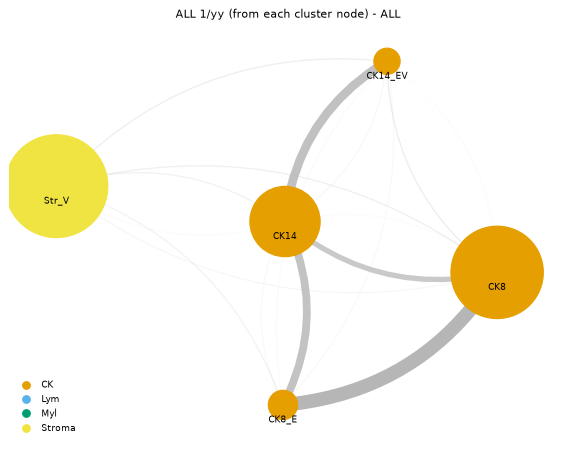

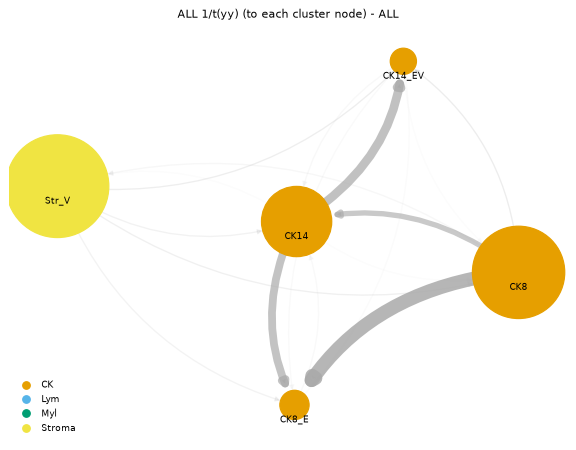

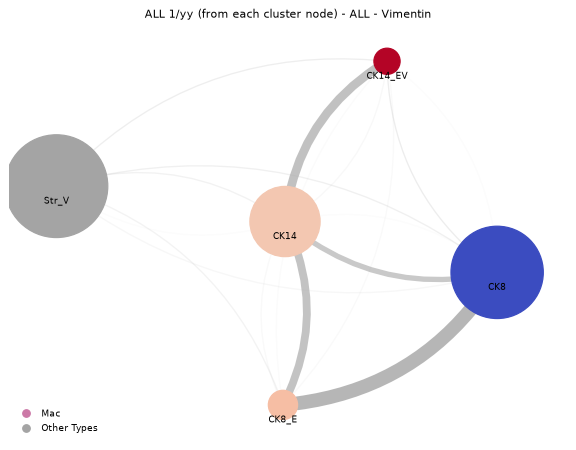

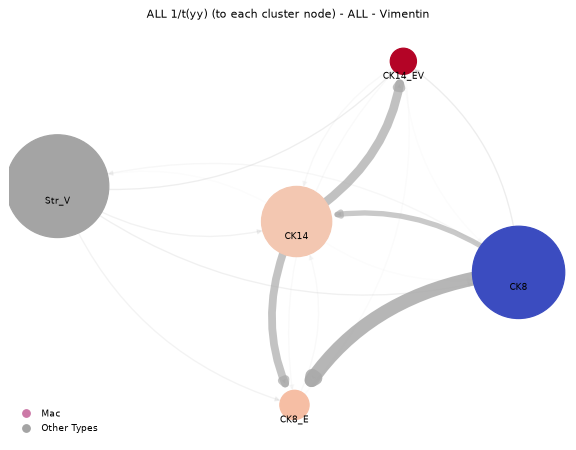

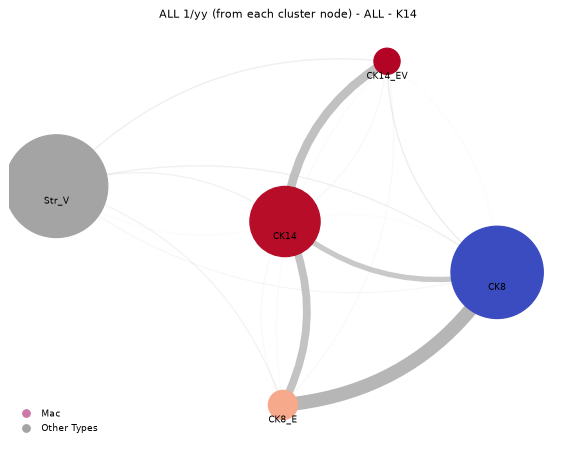

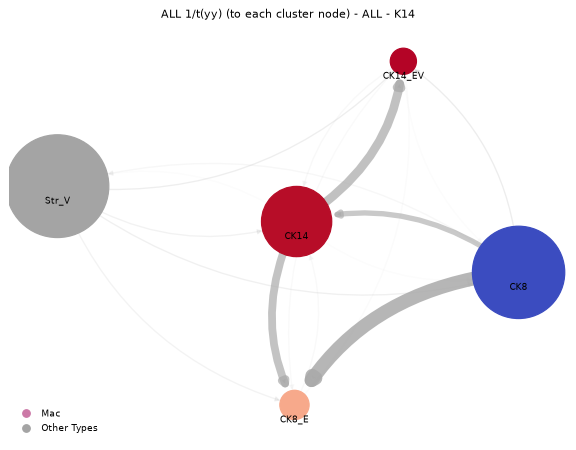

→ D:\ELOISE\EXP112\ROI_9x7\Results_spatialdata\Distance_Relationships.pdf


In [39]:
# 🖐️ INTERACTIF
NETWORK_SEED = 1234

if "mats" not in globals():   # reprise après redémarrage : relecture des matrices de la partie 4
    globals().update(load_state("state_part4.pkl"))
    mats = {os.path.basename(f)[5:-8]: pd.read_parquet(f).set_index("ctype") for f in glob.glob(os.path.join(OUT_DIR, "dist_*.parquet"))}

def mean_dist_matrix(m):
    a = m.groupby(level=0).mean()
    a.index = [int(s[5:]) for s in a.index]; a.columns = [int(c[5:]) for c in a.columns]
    keep = sorted(set(a.index) & set(a.columns) - {CT2NUM.get("Neuron", -1)})
    return a.loc[keep, keep]

dist_m = {k: mean_dist_matrix(v) for k, v in mats.items()}
_m = cells.groupby("cell_clustering1m")[[c for c in ["K8", "K14", "Ecadh", "Vimentin"] if c in cells]].mean().reindex(CLUSTERLEVELS)
exprdf = (_m - _m.mean()) / _m.std(ddof=1)
GREY, PINK = "#A4A4A4", "#CC79A7"
main_levels = sorted({maintype_of(c) for c in CLUSTERLEVELS} - {"Other"})
col_main = {CT2NUM[c]: CBB_PALETTE[main_levels.index(maintype_of(c))] for c in CLUSTERLEVELS if maintype_of(c) != "Other"}

def col_expr(marker):
    ck = [c for c in CK_TYPES if c in exprdf.index and np.isfinite(exprdf.loc[c, marker])]
    cols = dict(zip(ck, num2col(exprdf.loc[ck, marker], COOLWARM))) if ck else {}
    return {CT2NUM[c]: (PINK if c in MAC_TYPES else cols.get(c, GREY)) for c in CLUSTERLEVELS}

def draw_network(W, pct_, colors, title, arrows, maximum, legend, ax, minimum=1 / 250):
    nodes = list(W.index); G = nx.DiGraph(); G.add_nodes_from(nodes)
    for i in nodes:
        for j in nodes:
            w = W.loc[i, j]
            if i != j and np.isfinite(w) and w >= minimum: G.add_edge(i, j, weight=float(w))
    U = nx.Graph(); U.add_nodes_from(nodes)
    for i, j, d in G.edges(data=True):
        U.add_edge(i, j, weight=U.get_edge_data(i, j, {"weight": 0})["weight"] + d["weight"])
    pos = nx.spring_layout(U, weight="weight", seed=NETWORK_SEED, iterations=200)
    vsize = np.array([np.log(1.5 + pct_.get(CLUSTERLEVELS[n - 1], 0)) * 3 for n in nodes])
    ws = np.sort([d["weight"] for *_, d in G.edges(data=True)])[::-1]
    esize = 15 * np.exp(-len(nodes) / 90) + 1
    cut = max(ws[min(2 * len(nodes), len(ws)) - 1], np.quantile(ws, .75)) if len(ws) else 0
    for i, j, d in G.edges(data=True):
        w = d["weight"]; r = w / maximum
        width = 1 if w <= cut else 1 + (esize - 1) * (w - cut) / max(maximum - cut, 1e-12)
        nx.draw_networkx_edges(G, pos, edgelist=[(i, j)], ax=ax, width=.6 * 1.75 * width, alpha=float(np.clip(r if w > cut else r * .4, .03, 1)),
                               edge_color="darkgray", arrows=True, arrowstyle="-|>" if arrows else "-", arrowsize=8,
                               connectionstyle="arc3,rad=0.25", node_size=(vsize * 7) ** 2)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=(vsize * 7) ** 2, node_color=[colors.get(n, GREY) for n in nodes])
    for n in nodes:
        ax.text(pos[n][0], pos[n][1] - .06, CLUSTERLEVELS[n - 1], ha="center", va="top", fontsize=7)
    ax.set_title(title, fontsize=9); ax.axis("off"); ax.legend(handles=legend, loc="lower left", frameon=False, fontsize=7)

LEG_MAIN = [plt.Line2D([], [], marker="o", ls="", color=CBB_PALETTE[i], label=m) for i, m in enumerate(main_levels)]
LEG_MAC = [plt.Line2D([], [], marker="o", ls="", color=PINK, label="Mac"), plt.Line2D([], [], marker="o", ls="", color=GREY, label="Other Types")]
maximum = np.nanmax([np.nanmax(1 / dist_m[g].values) for g in GROUPS])
colorings = [("", col_main, LEG_MAIN)] + [(f" - {m}", col_expr(m), LEG_MAC) for m in ["Vimentin", "K14"] if m in exprdf]
with FigPDF("Distance_Relationships.pdf") as pdf:
    for key, yy in dist_m.items():
        g = key[:3] if key[:3] in pct else GROUPS[0]
        lab = "PRI" if key.endswith("pri") else "MET" if key.endswith("met") else "ALL"
        for suf, colors, leg in colorings:
            for direction, W, arrows in [("from", 1 / yy, False), ("to", 1 / yy.T, True)]:
                fig, ax = plt.subplots(figsize=(8, 6))
                draw_network(W, pct[g], colors, f"{g} 1/{'yy' if direction == 'from' else 't(yy)'} ({direction} each cluster node) - {lab}{suf}",
                             arrows, maximum, leg, ax)
                pdf.add(fig)

## 5.2 Comparaison des distances à partir d'un type (`Results_distances_*.csv`, `Distance_violinplots.pdf`)

Adaptation de `dist_ttest` (le code R d'origine référençait des objets d'un autre projet) : test t de Welch des distances d'un type de départ vers chaque type, entre deux sous-ensembles.

> 🖐️ **INTERACTIF** — type de départ, sous-ensembles comparés (clés disponibles affichées), types cibles des violons.

In [ ]:
print("Sous-ensembles disponibles :", list(mats))
# 🖐️ INTERACTIF
FROM_TYPE = "Tc"
GROUP1 = list(mats)[1] if len(mats) > 2 else list(mats)[0]
GROUP2 = list(mats)[2] if len(mats) > 2 else list(mats)[-1]
VIOLIN_TARGETS = [c for c in ["Treg", "B"] + MAC_TYPES if c in CT2NUM]
VIOLIN_YMAX = 500

from statsmodels.stats.multitest import multipletests
if FROM_TYPE in CT2NUM:
    g1, g2 = mats[GROUP1], mats[GROUP2]; c1 = f"ctype{CT2NUM[FROM_TYPE]}"
    rows = []
    for tgt in CLUSTERLEVELS:
        c2 = f"ctype{CT2NUM[tgt]}"
        a = g1.loc[g1.index == c1, c2].dropna().to_numpy() if c2 in g1 else np.array([])
        b = g2.loc[g2.index == c1, c2].dropna().to_numpy() if c2 in g2 else np.array([])
        rows.append({"target": tgt, "G1_mean": a.mean() if len(a) else np.nan, "G2_mean": b.mean() if len(b) else np.nan,
                     "G1_median": np.median(a) if len(a) else np.nan, "G2_median": np.median(b) if len(b) else np.nan,
                     "pvalue": stats.ttest_ind(a, b, equal_var=False).pvalue if len(a) > 1 and len(b) > 1 else np.nan})
    res = pd.DataFrame(rows); res["diff_mean"] = res["G1_mean"] - res["G2_mean"]; res["diff_med"] = res["G1_median"] - res["G2_median"]
    ok = res["pvalue"].notna()
    if ok.any(): res.loc[ok, "padj"] = multipletests(res.loc[ok, "pvalue"], method="fdr_bh")[1]
    res.to_csv(os.path.join(OUT_DIR, f"Results_distances_{FROM_TYPE}_{GROUP1}_vs_{GROUP2}.csv"), index=False)
    display(res.round(4))
    with FigPDF("Distance_violinplots.pdf") as pdf:
        for tgt in VIOLIN_TARGETS:
            c2 = f"ctype{CT2NUM[tgt]}"
            parts = [pd.DataFrame({"group": n, "distance": m.loc[m.index == c1, c2].dropna().values}) for n, m in [(GROUP1, g1), (GROUP2, g2)] if c2 in m]
            d = pd.concat(parts) if parts else pd.DataFrame(columns=["group", "distance"])
            d = d[d["distance"] <= VIOLIN_YMAX]
            if d.empty: print(f"{FROM_TYPE} → {tgt} : pas de données"); continue
            fig, ax = plt.subplots(figsize=(3, 3))
            sns.violinplot(data=d, x="group", y="distance", hue="group", ax=ax, legend=False, cut=0)
            ax.set_ylim(0, VIOLIN_YMAX); ax.set_ylabel("distance (µm)"); ax.set_title(f"{FROM_TYPE} → {tgt}"); pdf.add(fig)

---
## Fin — fichiers produits

Les objets `regXXX.zarr` (images, labels, cercles, table annotée) sont réutilisables dans tout l'écosystème scverse (`squidpy`, `napari-spatialdata` en local pour une exploration interactive des images, etc.).

In [ ]:
for f in sorted(os.listdir(OUT_DIR)):
    print(f"{os.path.getsize(os.path.join(OUT_DIR, f)) / 1e6:8.2f} Mo  {f}")